In [14]:
import pandas as pd

In [15]:
import os
import sys

# Project root ko Python path me add karo
project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(project_root)

d:\Internshipp


In [16]:
df = pd.read_csv("../data/raw_data.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw_data.csv'

In [ ]:
df.shape

(603, 12)

In [ ]:
df.head()

,student_id,student_name,class_id,subject,topic,assessment_name,marks_obtained,total_marks,attempt_date,time_taken,questions_attempted,questions_correct
0,S012,Dev,10A,Chemistry,Inorganic Chemistry,Assessment 1,82,100,2026-07-01,32.0,45,37
1,S053,Sarthak,10C,Mathematics,Algebra,Assessment 8,74,100,2026-08-14,37.0,40,30
2,S057,Tushar,10C,Physics,Thermodynamics,Assessment 8,74,100,2026-08-13,55.0,31,23
3,S008,Kabir,10A,Computer Science,Computer Networks,Assessment 8,61,100,2026-08-12,26.0,42,26
4,S019,Isha,10A,Physics,Current Electricity,Assessment 2,71,100,2026-07-07,45.0,37,26


In [ ]:
df.columns

Index(['student_id', 'student_name', 'class_id', 'subject', 'topic',
       'assessment_name', 'marks_obtained', 'total_marks', 'attempt_date',
       'time_taken', 'questions_attempted', 'questions_correct'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 603 entries, 0 to 602
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           603 non-null    str    
 1   student_name         603 non-null    str    
 2   class_id             603 non-null    str    
 3   subject              603 non-null    str    
 4   topic                600 non-null    str    
 5   assessment_name      603 non-null    str    
 6   marks_obtained       603 non-null    int64  
 7   total_marks          603 non-null    int64  
 8   attempt_date         603 non-null    str    
 9   time_taken           600 non-null    float64
 10  questions_attempted  603 non-null    int64  
 11  questions_correct    603 non-null    int64  
dtypes: float64(1), int64(4), str(7)
memory usage: 90.7 KB


In [ ]:
df.describe()

,marks_obtained,total_marks,time_taken,questions_attempted,questions_correct
count,603.000000,603.0,600.000000,603.000000,603.000000
mean,71.676617,100.0,43.398333,40.263682,28.847430
std,11.333801,0.0,10.206368,5.979627,6.296121
min,40.000000,100.0,25.000000,30.000000,13.000000
25%,64.000000,100.0,34.000000,35.000000,24.000000
50%,72.000000,100.0,44.000000,41.000000,28.000000
75%,81.000000,100.0,53.000000,45.000000,33.000000
max,120.000000,100.0,60.000000,50.000000,44.000000


In [ ]:
df.isnull().sum()

student_id             0
student_name           0
class_id               0
subject                0
topic                  3
assessment_name        0
marks_obtained         0
total_marks            0
attempt_date           0
time_taken             3
questions_attempted    0
questions_correct      0
dtype: int64

In [ ]:
invalid_marks = df[
    df["marks_obtained"] > df["total_marks"]
]

invalid_marks

,student_id,student_name,class_id,subject,topic,assessment_name,marks_obtained,total_marks,attempt_date,time_taken,questions_attempted,questions_correct
114,S060,Gaurav,10C,Chemistry,Inorganic Chemistry,Assessment 1,107,100,2026-07-03,47.0,45,38
220,S018,Aanya,10A,Computer Science,Computer Networks,Assessment 3,120,100,2026-07-14,51.0,47,37
308,S017,Diya,10A,Physics,Optics,Assessment 3,109,100,2026-07-14,37.0,35,22


In [ ]:
invalid_marks.shape

(3, 12)

In [ ]:
invalid_questions = df[
    df["questions_correct"] > df["questions_attempted"]
]

invalid_questions

,student_id,student_name,class_id,subject,topic,assessment_name,marks_obtained,total_marks,attempt_date,time_taken,questions_attempted,questions_correct
347,S004,Arjun,10A,Chemistry,Chemical Bonding,Assessment 9,79,100,2026-08-18,40.0,40,43
461,S055,Pranav,10C,Computer Science,DBMS,Assessment 7,60,100,2026-08-06,37.0,36,37
481,S001,Aarav,10A,Mathematics,Probability,Assessment 5,81,100,2026-07-25,NaN,31,33


In [ ]:
invalid_questions.shape

(3, 12)

In [ ]:
duplicates = df[
    df.duplicated()
]

duplicates

,student_id,student_name,class_id,subject,topic,assessment_name,marks_obtained,total_marks,attempt_date,time_taken,questions_attempted,questions_correct
129,S049,Aman,10C,Mathematics,Probability,Assessment 9,70,100,2026-08-18,32.0,33,23
475,S040,Vihaan,10B,Physics,Mechanics,Assessment 3,40,100,2026-07-13,55.0,48,19
537,S044,Shivansh,10C,Mathematics,Geometry,Assessment 10,76,100,not-a-date,53.0,40,31


In [ ]:
duplicates.shape

(3, 12)

In [ ]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
598    False
599    False
600    False
601    False
602    False
Length: 603, dtype: bool

In [ ]:
pd.to_datetime(
    df["attempt_date"],
    errors="coerce"
)

0     2026-07-01
1     2026-08-14
2     2026-08-13
3     2026-08-12
4     2026-07-07
         ...    
598   2026-07-07
599   2026-08-06
600   2026-07-01
601   2026-08-02
602   2026-07-14
Name: attempt_date, Length: 603, dtype: datetime64[us]

In [ ]:
parsed_dates = pd.to_datetime(
    df["attempt_date"],
    errors="coerce"
)

invalid_dates = df[
    parsed_dates.isna()
]

invalid_dates

,student_id,student_name,class_id,subject,topic,assessment_name,marks_obtained,total_marks,attempt_date,time_taken,questions_attempted,questions_correct
231,S045,Mohit,10C,Computer Science,Data Structures,Assessment 5,66,100,2026-99-99,48.0,47,31
283,S044,Shivansh,10C,Mathematics,Geometry,Assessment 10,76,100,not-a-date,53.0,40,31
537,S044,Shivansh,10C,Mathematics,Geometry,Assessment 10,76,100,not-a-date,53.0,40,31
584,S042,Atharv,10C,Chemistry,Chemical Bonding,Assessment 4,76,100,2026/35/80,55.0,36,28


In [ ]:
df.inf()

AttributeError: 'DataFrame' object has no attribute 'inf'

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 603 entries, 0 to 602
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           603 non-null    str    
 1   student_name         603 non-null    str    
 2   class_id             603 non-null    str    
 3   subject              603 non-null    str    
 4   topic                600 non-null    str    
 5   assessment_name      603 non-null    str    
 6   marks_obtained       603 non-null    int64  
 7   total_marks          603 non-null    int64  
 8   attempt_date         603 non-null    str    
 9   time_taken           600 non-null    float64
 10  questions_attempted  603 non-null    int64  
 11  questions_correct    603 non-null    int64  
dtypes: float64(1), int64(4), str(7)
memory usage: 90.7 KB


In [ ]:
df.describe()

,marks_obtained,total_marks,time_taken,questions_attempted,questions_correct
count,603.000000,603.0,600.000000,603.000000,603.000000
mean,71.676617,100.0,43.398333,40.263682,28.847430
std,11.333801,0.0,10.206368,5.979627,6.296121
min,40.000000,100.0,25.000000,30.000000,13.000000
25%,64.000000,100.0,34.000000,35.000000,24.000000
50%,72.000000,100.0,44.000000,41.000000,28.000000
75%,81.000000,100.0,53.000000,45.000000,33.000000
max,120.000000,100.0,60.000000,50.000000,44.000000


In [ ]:
df.isnull().sum()


student_id             0
student_name           0
class_id               0
subject                0
topic                  3
assessment_name        0
marks_obtained         0
total_marks            0
attempt_date           0
time_taken             3
questions_attempted    0
questions_correct      0
dtype: int64

In [ ]:
invalid_marks = df[df["marks_obtained"] > df["total_marks"]]
invalid_marks

,student_id,student_name,class_id,subject,topic,assessment_name,marks_obtained,total_marks,attempt_date,time_taken,questions_attempted,questions_correct
114,S060,Gaurav,10C,Chemistry,Inorganic Chemistry,Assessment 1,107,100,2026-07-03,47.0,45,38
220,S018,Aanya,10A,Computer Science,Computer Networks,Assessment 3,120,100,2026-07-14,51.0,47,37
308,S017,Diya,10A,Physics,Optics,Assessment 3,109,100,2026-07-14,37.0,35,22


In [ ]:
invalid_questions = df[df["questions_correct"] > df["questions_attempted"]]
invalid_questions

,student_id,student_name,class_id,subject,topic,assessment_name,marks_obtained,total_marks,attempt_date,time_taken,questions_attempted,questions_correct
347,S004,Arjun,10A,Chemistry,Chemical Bonding,Assessment 9,79,100,2026-08-18,40.0,40,43
461,S055,Pranav,10C,Computer Science,DBMS,Assessment 7,60,100,2026-08-06,37.0,36,37
481,S001,Aarav,10A,Mathematics,Probability,Assessment 5,81,100,2026-07-25,NaN,31,33


In [ ]:
duplicates = df[df.duplicated()]
duplicates

,student_id,student_name,class_id,subject,topic,assessment_name,marks_obtained,total_marks,attempt_date,time_taken,questions_attempted,questions_correct
129,S049,Aman,10C,Mathematics,Probability,Assessment 9,70,100,2026-08-18,32.0,33,23
475,S040,Vihaan,10B,Physics,Mechanics,Assessment 3,40,100,2026-07-13,55.0,48,19
537,S044,Shivansh,10C,Mathematics,Geometry,Assessment 10,76,100,not-a-date,53.0,40,31


In [ ]:
parsed_dates = pd.to_datetime(df["attempt_date"], errors="coerce")
invalid_dates = df[parsed_dates.isna()]
invalid_dates

,student_id,student_name,class_id,subject,topic,assessment_name,marks_obtained,total_marks,attempt_date,time_taken,questions_attempted,questions_correct
231,S045,Mohit,10C,Computer Science,Data Structures,Assessment 5,66,100,2026-99-99,48.0,47,31
283,S044,Shivansh,10C,Mathematics,Geometry,Assessment 10,76,100,not-a-date,53.0,40,31
537,S044,Shivansh,10C,Mathematics,Geometry,Assessment 10,76,100,not-a-date,53.0,40,31
584,S042,Atharv,10C,Chemistry,Chemical Bonding,Assessment 4,76,100,2026/35/80,55.0,36,28


In [ ]:
missing_rows = df[df.isnull().any(axis=1)]
missing_rows

,student_id,student_name,class_id,subject,topic,assessment_name,marks_obtained,total_marks,attempt_date,time_taken,questions_attempted,questions_correct
95,S029,Shreya,10B,Computer Science,NaN,Assessment 1,83,100,2026-07-02,54.0,41,34
164,S033,Anjali,10B,Chemistry,Chemical Bonding,Assessment 1,81,100,2026-07-03,NaN,45,36
336,S006,Rahul,10A,Physics,Thermodynamics,Assessment 10,57,100,2026-08-25,NaN,40,23
406,S047,Abhishek,10C,Chemistry,NaN,Assessment 3,58,100,2026-07-13,35.0,50,29
481,S001,Aarav,10A,Mathematics,Probability,Assessment 5,81,100,2026-07-25,NaN,31,33
594,S022,Riya,10B,Physics,NaN,Assessment 5,66,100,2026-07-26,30.0,46,30


In [ ]:
df["marks_obtained"] > df["total_marks"]

0      False
1      False
2      False
3      False
4      False
       ...  
598    False
599    False
600    False
601    False
602    False
Length: 603, dtype: bool

In [ ]:
valid_marks = df["marks_obtained"] <= df["total_marks"]

In [ ]:
df["questions_correct"] > df["questions_attempted"]

0      False
1      False
2      False
3      False
4      False
       ...  
598    False
599    False
600    False
601    False
602    False
Length: 603, dtype: bool

In [ ]:
valid_questions = (
    df["questions_correct"]
    <= df["questions_attempted"]
)

In [ ]:
parsed_dates = pd.to_datetime(
    df["attempt_date"],
    errors="coerce"
)

In [ ]:
df["attempt_date"] = parsed_dates

In [ ]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
598    False
599    False
600    False
601    False
602    False
Length: 603, dtype: bool

In [ ]:
df = df.drop_duplicates()

In [ ]:
clean_df = df.copy()

In [ ]:
print("Original rows:", len(clean_df))

Original rows: 600


In [ ]:
clean_df = clean_df.dropna(
    subset=["topic", "time_taken"]
)

In [ ]:
print("After missing-value removal:", len(clean_df))

After missing-value removal: 594


In [ ]:
clean_df = clean_df[
    clean_df["marks_obtained"]
    <= clean_df["total_marks"]
]

In [ ]:
clean_df = clean_df[
    clean_df["questions_correct"]
    <= clean_df["questions_attempted"]
]

In [ ]:
clean_df["attempt_date"] = pd.to_datetime(
    clean_df["attempt_date"],
    errors="coerce"
)

In [ ]:
clean_df = clean_df.dropna(
    subset=["attempt_date"]
)

In [ ]:
clean_df = clean_df.drop_duplicates()

In [ ]:
print("Original rows:", len(df))
print("Clean rows:", len(clean_df))
print("Rows removed:", len(df) - len(clean_df))

Original rows: 600
Clean rows: 586
Rows removed: 14


In [ ]:
clean_df.isnull().sum()

student_id             0
student_name           0
class_id               0
subject                0
topic                  0
assessment_name        0
marks_obtained         0
total_marks            0
attempt_date           0
time_taken             0
questions_attempted    0
questions_correct      0
dtype: int64

In [ ]:
print(
    "Invalid marks:",
    (
        clean_df["marks_obtained"]
        > clean_df["total_marks"]
    ).sum()
)

Invalid marks: 0


In [ ]:
print(
    "Invalid questions:",
    (
        clean_df["questions_correct"]
        > clean_df["questions_attempted"]
    ).sum()
)

Invalid questions: 0


In [ ]:
print(
    "Duplicates:",
    clean_df.duplicated().sum()
)

Duplicates: 0


In [ ]:
clean_df["score_percentage"] = (
    clean_df["marks_obtained"]
    / clean_df["total_marks"]
    * 100
)

In [ ]:
clean_df[
    [
        "marks_obtained",
        "total_marks",
        "score_percentage"
    ]
].head()

,marks_obtained,total_marks,score_percentage
0,82,100,82.0
1,74,100,74.0
2,74,100,74.0
3,61,100,61.0
4,71,100,71.0


In [ ]:
clean_df["accuracy"] = (
    clean_df["questions_correct"]
    / clean_df["questions_attempted"]
    * 100
)

In [ ]:
clean_df[
    [
        "questions_attempted",
        "questions_correct",
        "accuracy"
    ]
].head()

,questions_attempted,questions_correct,accuracy
0,45,37,82.222222
1,40,30,75.000000
2,31,23,74.193548
3,42,26,61.904762
4,37,26,70.270270


In [ ]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 586 entries, 0 to 602
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   student_id           586 non-null    str           
 1   student_name         586 non-null    str           
 2   class_id             586 non-null    str           
 3   subject              586 non-null    str           
 4   topic                586 non-null    str           
 5   assessment_name      586 non-null    str           
 6   marks_obtained       586 non-null    int64         
 7   total_marks          586 non-null    int64         
 8   attempt_date         586 non-null    datetime64[us]
 9   time_taken           586 non-null    float64       
 10  questions_attempted  586 non-null    int64         
 11  questions_correct    586 non-null    int64         
 12  score_percentage     586 non-null    float64       
 13  accuracy             586 non-null    float64       

In [ ]:
clean_df.describe()

,marks_obtained,total_marks,attempt_date,time_taken,questions_attempted,questions_correct,score_percentage,accuracy
count,586.00000,586.0,586,586.000000,586.000000,586.000000,586.00000,586.000000
mean,71.52901,100.0,2026-07-29 02:22:31.535836,43.365188,40.237201,28.788396,71.52901,71.519352
min,40.00000,100.0,2026-07-01 00:00:00,25.000000,30.000000,13.000000,40.00000,39.583333
25%,64.00000,100.0,2026-07-14 00:00:00,34.000000,35.000000,24.000000,64.00000,63.829787
50%,72.00000,100.0,2026-07-31 00:00:00,44.000000,41.000000,28.000000,72.00000,72.340426
75%,81.00000,100.0,2026-08-13 00:00:00,53.000000,45.000000,33.000000,81.00000,80.927052
max,89.00000,100.0,2026-08-26 00:00:00,60.000000,50.000000,44.000000,89.00000,90.322581
std,10.96381,0.0,NaN,10.233667,5.991166,6.286842,10.96381,10.964733


In [ ]:
clean_df.to_csv(
    "../data/processed_data.csv",
    index=False
)

In [ ]:
processed_df = pd.read_csv(
    "../data/processed_data.csv"
)

processed_df.shape

In [ ]:
print("Rows:", len(clean_df))
print("Columns:", len(clean_df.columns))

print("\nMissing values:")
print(clean_df.isnull().sum())

print("\nInvalid marks:")
print(
    (
        clean_df["marks_obtained"]
        > clean_df["total_marks"]
    ).sum()
)

print("\nInvalid questions:")
print(
    (
        clean_df["questions_correct"]
        > clean_df["questions_attempted"]
    ).sum()
)

print("\nDuplicate rows:")
print(clean_df.duplicated().sum())

print("\nInvalid dates:")
print(
    pd.to_datetime(
        clean_df["attempt_date"],
        errors="coerce"
    ).isna().sum()
)

Rows: 586
Columns: 14

Missing values:
student_id             0
student_name           0
class_id               0
subject                0
topic                  0
assessment_name        0
marks_obtained         0
total_marks            0
attempt_date           0
time_taken             0
questions_attempted    0
questions_correct      0
score_percentage       0
accuracy               0
dtype: int64

Invalid marks:
0

Invalid questions:
0

Duplicate rows:
0

Invalid dates:
0


In [ ]:
def clean_data(df):
    """
    Clean the raw student assessment dataset.

    Returns:
        pd.DataFrame: Cleaned dataset with derived metrics.
    """

    clean_df = df.copy()

    # Remove rows with essential missing values
    clean_df = clean_df.dropna(
        subset=["topic", "time_taken"]
    )

    # Remove invalid marks
    clean_df = clean_df[
        clean_df["marks_obtained"]
        <= clean_df["total_marks"]
    ]

    # Remove invalid question counts
    clean_df = clean_df[
        clean_df["questions_correct"]
        <= clean_df["questions_attempted"]
    ]

    # Convert dates
    clean_df["attempt_date"] = pd.to_datetime(
        clean_df["attempt_date"],
        errors="coerce"
    )

    # Remove invalid dates
    clean_df = clean_df.dropna(
        subset=["attempt_date"]
    )

    # Remove duplicate records
    clean_df = clean_df.drop_duplicates()

    # Calculate score percentage
    clean_df["score_percentage"] = (
        clean_df["marks_obtained"]
        / clean_df["total_marks"]
        * 100
    )

    # Calculate accuracy
    clean_df["accuracy"] = (
        clean_df["questions_correct"]
        / clean_df["questions_attempted"]
        * 100
    )

    return clean_df

In [ ]:
raw_df = pd.read_csv(
    "../data/raw_data.csv"
)

In [ ]:
final_df = clean_data(raw_df)

In [ ]:
final_df.shape

(586, 14)

In [ ]:
final_df.head()

,student_id,student_name,class_id,subject,topic,assessment_name,marks_obtained,total_marks,attempt_date,time_taken,questions_attempted,questions_correct,score_percentage,accuracy
0,S012,Dev,10A,Chemistry,Inorganic Chemistry,Assessment 1,82,100,2026-07-01,32.0,45,37,82.0,82.222222
1,S053,Sarthak,10C,Mathematics,Algebra,Assessment 8,74,100,2026-08-14,37.0,40,30,74.0,75.000000
2,S057,Tushar,10C,Physics,Thermodynamics,Assessment 8,74,100,2026-08-13,55.0,31,23,74.0,74.193548
3,S008,Kabir,10A,Computer Science,Computer Networks,Assessment 8,61,100,2026-08-12,26.0,42,26,61.0,61.904762
4,S019,Isha,10A,Physics,Current Electricity,Assessment 2,71,100,2026-07-07,45.0,37,26,71.0,70.270270


In [ ]:
print("Manual cleaning rows:", len(clean_df))
print("Function cleaning rows:", len(final_df))

Manual cleaning rows: 586
Function cleaning rows: 586


In [ ]:
print(
    final_df[
        ["score_percentage", "accuracy"]
    ].head()
)

   score_percentage   accuracy
0              82.0  82.222222
1              74.0  75.000000
2              74.0  74.193548
3              61.0  61.904762
4              71.0  70.270270


In [ ]:
original_rows = len(raw_df)
cleaned_rows = len(final_df)
removed_rows = original_rows - cleaned_rows

removal_percentage = (
    removed_rows / original_rows
) * 100

print(f"Original rows: {original_rows}")
print(f"Cleaned rows: {cleaned_rows}")
print(f"Rows removed: {removed_rows}")
print(
    f"Removal percentage: {removal_percentage:.2f}%"
)

Original rows: 603
Cleaned rows: 586
Rows removed: 17
Removal percentage: 2.82%


In [ ]:
final_df.to_csv(
    "../data/processed_data.csv",
    index=False
)

In [ ]:
pd.read_csv(
    "../data/processed_data.csv"
).shape

(586, 14)

In [ ]:
# Phase 2 complete

# Phase 2 complete

In [ ]:
processed_df = pd.read_csv(
    "../data/processed_data.csv"
)

processed_df.head()

,student_id,student_name,class_id,subject,topic,assessment_name,marks_obtained,total_marks,attempt_date,time_taken,questions_attempted,questions_correct,score_percentage,accuracy
0,S012,Dev,10A,Chemistry,Inorganic Chemistry,Assessment 1,82,100,2026-07-01,32.0,45,37,82.0,82.222222
1,S053,Sarthak,10C,Mathematics,Algebra,Assessment 8,74,100,2026-08-14,37.0,40,30,74.0,75.000000
2,S057,Tushar,10C,Physics,Thermodynamics,Assessment 8,74,100,2026-08-13,55.0,31,23,74.0,74.193548
3,S008,Kabir,10A,Computer Science,Computer Networks,Assessment 8,61,100,2026-08-12,26.0,42,26,61.0,61.904762
4,S019,Isha,10A,Physics,Current Electricity,Assessment 2,71,100,2026-07-07,45.0,37,26,71.0,70.270270


In [ ]:
processed_df.shape

(586, 14)

In [ ]:
processed_df.columns

Index(['student_id', 'student_name', 'class_id', 'subject', 'topic',
       'assessment_name', 'marks_obtained', 'total_marks', 'attempt_date',
       'time_taken', 'questions_attempted', 'questions_correct',
       'score_percentage', 'accuracy'],
      dtype='str')

In [ ]:
processed_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 586 entries, 0 to 585
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           586 non-null    str    
 1   student_name         586 non-null    str    
 2   class_id             586 non-null    str    
 3   subject              586 non-null    str    
 4   topic                586 non-null    str    
 5   assessment_name      586 non-null    str    
 6   marks_obtained       586 non-null    int64  
 7   total_marks          586 non-null    int64  
 8   attempt_date         586 non-null    str    
 9   time_taken           586 non-null    float64
 10  questions_attempted  586 non-null    int64  
 11  questions_correct    586 non-null    int64  
 12  score_percentage     586 non-null    float64
 13  accuracy             586 non-null    float64
dtypes: float64(3), int64(4), str(7)
memory usage: 97.3 KB


In [ ]:
student_id = "S001"

In [ ]:
student_df = processed_df[
    processed_df["student_id"] == student_id
]

student_df

,student_id,student_name,class_id,subject,topic,assessment_name,marks_obtained,total_marks,attempt_date,time_taken,questions_attempted,questions_correct,score_percentage,accuracy
20,S001,Aarav,10A,Mathematics,Probability,Assessment 3,81,100,2026-07-14,29.0,38,31,81.0,81.578947
71,S001,Aarav,10A,Mathematics,Geometry,Assessment 7,88,100,2026-08-07,54.0,50,44,88.0,88.000000
119,S001,Aarav,10A,Computer Science,Data Structures,Assessment 10,88,100,2026-08-24,35.0,34,30,88.0,88.235294
146,S001,Aarav,10A,Chemistry,Inorganic Chemistry,Assessment 1,80,100,2026-07-03,43.0,37,29,80.0,78.378378
213,S001,Aarav,10A,Mathematics,Probability,Assessment 8,81,100,2026-08-12,59.0,47,38,81.0,80.851064
266,S001,Aarav,10A,Computer Science,Operating Systems,Assessment 6,81,100,2026-07-31,45.0,48,39,81.0,81.250000
275,S001,Aarav,10A,Mathematics,Calculus,Assessment 4,84,100,2026-07-19,60.0,38,32,84.0,84.210526
321,S001,Aarav,10A,Chemistry,Thermodynamics,Assessment 9,83,100,2026-08-20,33.0,37,31,83.0,83.783784
530,S001,Aarav,10A,Physics,Current Electricity,Assessment 2,83,100,2026-07-07,48.0,44,36,83.0,81.818182


In [ ]:
overall_score = student_df["score_percentage"].mean()

overall_score

np.float64(83.22222222222223)

In [ ]:
print(f"Overall Score: {overall_score:.2f}%")

Overall Score: 83.22%


In [ ]:
overall_accuracy = student_df["accuracy"].mean()

print(f"Overall Accuracy: {overall_accuracy:.2f}%")

Overall Accuracy: 83.12%


In [ ]:
subject_performance = (
    student_df
    .groupby("subject")["score_percentage"]
    .mean()
)

subject_performance

subject
Chemistry           81.5
Computer Science    84.5
Mathematics         83.5
Physics             83.0
Name: score_percentage, dtype: float64

In [ ]:
strongest_subject = subject_performance.idxmax()

strongest_subject

'Computer Science'

In [ ]:
weakest_subject = subject_performance.idxmin()

weakest_subject

'Chemistry'

In [ ]:
topic_performance = (
    student_df
    .groupby("topic")["score_percentage"]
    .mean()
    .sort_values()
)

topic_performance

topic
Inorganic Chemistry    80.0
Operating Systems      81.0
Probability            81.0
Current Electricity    83.0
Thermodynamics         83.0
Calculus               84.0
Geometry               88.0
Data Structures        88.0
Name: score_percentage, dtype: float64

In [ ]:
weakest_topic = topic_performance.idxmin()

weakest_topic

'Inorganic Chemistry'

In [ ]:
strongest_topic = topic_performance.idxmax()

strongest_topic

'Geometry'

In [ ]:
student_id = "S001"

student_df = processed_df[
    processed_df["student_id"] == student_id
]

overall_score = student_df["score_percentage"].mean()
overall_accuracy = student_df["accuracy"].mean()

subject_performance = (
    student_df
    .groupby("subject")["score_percentage"]
    .mean()
)

topic_performance = (
    student_df
    .groupby("topic")["score_percentage"]
    .mean()
    .sort_values()
)

strongest_subject = subject_performance.idxmax()
weakest_subject = subject_performance.idxmin()

strongest_topic = topic_performance.idxmax()
weakest_topic = topic_performance.idxmin()

In [ ]:
print(f"Student: {student_id}")
print(f"Overall Score: {overall_score:.2f}%")
print(f"Overall Accuracy: {overall_accuracy:.2f}%")
print(f"Strongest Subject: {strongest_subject}")
print(f"Weakest Subject: {weakest_subject}")
print(f"Strongest Topic: {strongest_topic}")
print(f"Weakest Topic: {weakest_topic}")

Student: S001
Overall Score: 83.22%
Overall Accuracy: 83.12%
Strongest Subject: Computer Science
Weakest Subject: Chemistry
Strongest Topic: Geometry
Weakest Topic: Inorganic Chemistry


In [ ]:
student_df["attempt_date"] = pd.to_datetime(
    student_df["attempt_date"]
)

In [ ]:
student_df = student_df.sort_values(
    "attempt_date"
).reset_index(drop=True)

In [ ]:
student_df[
    [
        "assessment_name",
        "attempt_date",
        "score_percentage"
    ]
]

,assessment_name,attempt_date,score_percentage
0,Assessment 1,2026-07-03,80.0
1,Assessment 2,2026-07-07,83.0
2,Assessment 3,2026-07-14,81.0
3,Assessment 4,2026-07-19,84.0
4,Assessment 6,2026-07-31,81.0
5,Assessment 7,2026-08-07,88.0
6,Assessment 8,2026-08-12,81.0
7,Assessment 9,2026-08-20,83.0
8,Assessment 10,2026-08-24,88.0


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    student_df["attempt_date"],
    student_df["score_percentage"],
    marker="o"
)

plt.xlabel("Assessment Date")
plt.ylabel("Score Percentage")
plt.title(f"Performance Trend - {student_id}")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
!pip install matplotlib

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/88/89/56649bbaa2fd12e20f3be03dbcc135b0c8676d88bac17977599e3eb442a0/matplotlib-3.11.1-cp312-cp312-win_amd64.whl.metadata
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ------------------------------ --------- 61.4/80.3 kB 3.4 MB/s eta 0:00:01
     ---------------------------------------- 80.3/80.3 kB 1.5 MB/s eta 0:00:00
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/19/e8/6026ed58a64563186a9ee3f29f41261fd1828f527dd93d33b60feca63352/contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Obtaining dependency information for fonttools>=4.28.2 f


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


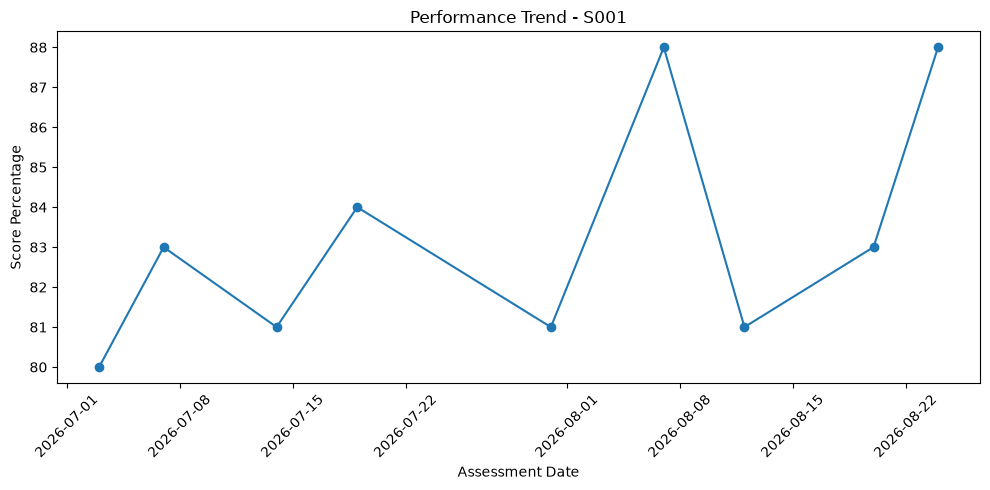

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    student_df["attempt_date"],
    student_df["score_percentage"],
    marker="o"
)

plt.xlabel("Assessment Date")
plt.ylabel("Score Percentage")
plt.title(f"Performance Trend - {student_id}")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# maths

In [ ]:
earlier_avg = (
    student_df
    .iloc[:5]["score_percentage"]
    .mean()
)

In [ ]:
recent_avg = (
    student_df
    .iloc[-5:]["score_percentage"]
    .mean()
)

In [ ]:
trend_difference = recent_avg - earlier_avg

print(f"Earlier Average: {earlier_avg:.2f}%")
print(f"Recent Average: {recent_avg:.2f}%")
print(f"Trend Difference: {trend_difference:.2f}%")

Earlier Average: 81.80%
Recent Average: 84.20%
Trend Difference: 2.40%


In [ ]:
if trend_difference >= 5:
    trend = "Improving"

elif trend_difference <= -5:
    trend = "Declining"

else:
    trend = "Stable"

print("Trend:", trend)

Trend: Stable


In [ ]:
student_id = "S016"

student_df = processed_df[
    processed_df["student_id"] == student_id
]

overall_score = student_df["score_percentage"].mean()
overall_accuracy = student_df["accuracy"].mean()

subject_performance = (
    student_df
    .groupby("subject")["score_percentage"]
    .mean()
)

topic_performance = (
    student_df
    .groupby("topic")["score_percentage"]
    .mean()
    .sort_values()
)

strongest_subject = subject_performance.idxmax()
weakest_subject = subject_performance.idxmin()

strongest_topic = topic_performance.idxmax()
weakest_topic = topic_performance.idxmin()

In [ ]:
print(f"Student: {student_id}")
print(f"Overall Score: {overall_score:.2f}%")
print(f"Overall Accuracy: {overall_accuracy:.2f}%")
print(f"Strongest Subject: {strongest_subject}")
print(f"Weakest Subject: {weakest_subject}")
print(f"Strongest Topic: {strongest_topic}")
print(f"Weakest Topic: {weakest_topic}")

Student: S016
Overall Score: 71.40%
Overall Accuracy: 71.15%
Strongest Subject: Physics
Weakest Subject: Mathematics
Strongest Topic: Organic Chemistry
Weakest Topic: Probability


In [ ]:
student_df["attempt_date"] = pd.to_datetime(
    student_df["attempt_date"]
)

In [ ]:
student_df = student_df.sort_values(
    "attempt_date"
).reset_index(drop=True)

In [ ]:
student_df[
    [
        "assessment_name",
        "attempt_date",
        "score_percentage"
    ]
]

,assessment_name,attempt_date,score_percentage
0,Assessment 1,2026-07-01,67.0
1,Assessment 2,2026-07-08,68.0
2,Assessment 3,2026-07-13,68.0
3,Assessment 4,2026-07-19,72.0
4,Assessment 5,2026-07-26,76.0
5,Assessment 6,2026-08-01,77.0
6,Assessment 7,2026-08-07,69.0
7,Assessment 8,2026-08-13,73.0
8,Assessment 9,2026-08-20,71.0
9,Assessment 10,2026-08-24,73.0


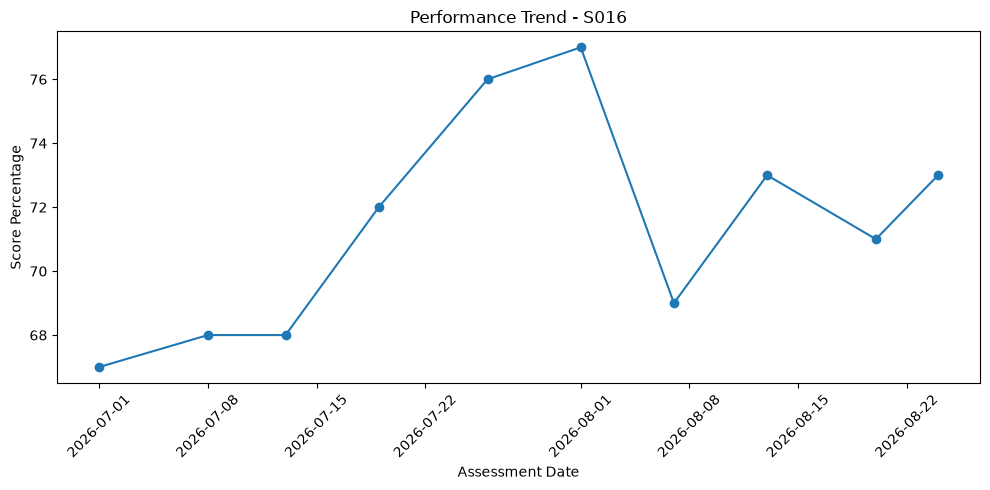

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    student_df["attempt_date"],
    student_df["score_percentage"],
    marker="o"
)

plt.xlabel("Assessment Date")
plt.ylabel("Score Percentage")
plt.title(f"Performance Trend - {student_id}")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
earlier_avg = (
    student_df
    .iloc[:5]["score_percentage"]
    .mean()
)

In [ ]:
recent_avg = (
    student_df
    .iloc[-5:]["score_percentage"]
    .mean()
)

In [ ]:
trend_difference = recent_avg - earlier_avg

print(f"Earlier Average: {earlier_avg:.2f}%")
print(f"Recent Average: {recent_avg:.2f}%")
print(f"Trend Difference: {trend_difference:.2f}%")

Earlier Average: 70.20%
Recent Average: 72.60%
Trend Difference: 2.40%


In [ ]:
if trend_difference >= 5:
    trend = "Improving"

elif trend_difference <= -5:
    trend = "Declining"

else:
    trend = "Stable"

print("Trend:", trend)

Trend: Stable


In [ ]:
student_insight = {
    "student_id": student_id,
    "student_name": student_df["student_name"].iloc[0],
    "class_id": student_df["class_id"].iloc[0],
    "overall_score": round(overall_score, 2),
    "overall_accuracy": round(overall_accuracy, 2),
    "strongest_subject": strongest_subject,
    "weakest_subject": weakest_subject,
    "strongest_topic": strongest_topic,
    "weakest_topic": weakest_topic,
    "earlier_average": round(earlier_avg, 2),
    "recent_average": round(recent_avg, 2),
    "trend_difference": round(trend_difference, 2),
    "trend": trend
}

In [ ]:
student_insight

{'student_id': 'S016',
 'student_name': 'Ananya',
 'class_id': '10A',
 'overall_score': np.float64(71.4),
 'overall_accuracy': np.float64(71.15),
 'strongest_subject': 'Physics',
 'weakest_subject': 'Mathematics',
 'strongest_topic': 'Organic Chemistry',
 'weakest_topic': 'Probability',
 'earlier_average': np.float64(70.2),
 'recent_average': np.float64(72.6),
 'trend_difference': np.float64(2.4),
 'trend': 'Stable'}

In [ ]:
pd.DataFrame([student_insight])

,student_id,student_name,class_id,overall_score,overall_accuracy,strongest_subject,weakest_subject,strongest_topic,weakest_topic,earlier_average,recent_average,trend_difference,trend
0,S016,Ananya,10A,71.4,71.15,Physics,Mathematics,Organic Chemistry,Probability,70.2,72.6,2.4,Stable


In [ ]:
if trend == "Declining":
    recommendation = (
        f"Focus on {weakest_topic} and review recent assessments "
        "to address the declining performance trend."
    )

elif trend == "Improving":
    recommendation = (
        f"Continue the current study strategy while strengthening "
        f"{weakest_topic}."
    )

else:
    recommendation = (
        f"Maintain consistent performance and focus on "
        f"improving {weakest_topic}."
    )

print(recommendation)

Maintain consistent performance and focus on improving Probability.


In [ ]:
student_insight["recommendation"] = recommendation

In [ ]:
student_insight

{'student_id': 'S016',
 'student_name': 'Ananya',
 'class_id': '10A',
 'overall_score': np.float64(71.4),
 'overall_accuracy': np.float64(71.15),
 'strongest_subject': 'Physics',
 'weakest_subject': 'Mathematics',
 'strongest_topic': 'Organic Chemistry',
 'weakest_topic': 'Probability',
 'earlier_average': np.float64(70.2),
 'recent_average': np.float64(72.6),
 'trend_difference': np.float64(2.4),
 'trend': 'Stable',
 'recommendation': 'Maintain consistent performance and focus on improving Probability.'}

In [ ]:
processed_df.groupby(
    "student_id"
)["score_percentage"].mean().sort_values()

student_id
S043    58.800000
S052    59.500000
S004    63.777778
S044    64.333333
S023    64.600000
S049    64.700000
S007    65.000000
S041    65.000000
S008    65.100000
S029    65.222222
S059    65.400000
S020    65.700000
S054    66.200000
S053    66.300000
S045    66.333333
S035    66.500000
S017    66.555556
S047    66.555556
S058    66.600000
S011    66.600000
S051    66.700000
S018    66.777778
S036    67.200000
S056    67.400000
S027    67.700000
S019    67.800000
S022    67.888889
S021    67.900000
S026    68.000000
S040    68.100000
S005    68.400000
S010    68.700000
S032    68.700000
S024    68.900000
S031    69.000000
S034    69.400000
S055    69.555556
S006    70.000000
S002    70.300000
S014    70.700000
S030    70.800000
S016    71.400000
S042    71.888889
S057    72.400000
S003    73.000000
S025    82.200000
S013    82.900000
S009    83.200000
S001    83.222222
S037    83.300000
S048    83.300000
S012    83.800000
S050    84.300000
S028    84.500000
S038    85.100000

In [ ]:
processed_df.groupby(
    "student_id"
)["accuracy"].mean().sort_values()

student_id
S043    58.779692
S052    59.589273
S004    63.235501
S049    64.019672
S044    64.228509
S023    64.258856
S007    64.635082
S008    65.001106
S059    65.275208
S041    65.371218
S029    65.710574
S020    65.794193
S054    66.278636
S047    66.340712
S011    66.380587
S017    66.515178
S051    66.618117
S035    66.633018
S018    66.645466
S045    66.696476
S053    66.762164
S058    66.786405
S036    67.576054
S021    67.603330
S056    67.697556
S019    67.778886
S026    67.812732
S005    67.993498
S040    68.080237
S022    68.198037
S027    68.261520
S010    68.406557
S024    69.012393
S031    69.021983
S032    69.031069
S055    69.241172
S034    69.355012
S006    70.127905
S014    70.499798
S002    70.523186
S030    70.943083
S016    71.150638
S042    71.686805
S057    72.357986
S003    72.981224
S025    82.242602
S009    83.018960
S037    83.052270
S048    83.086856
S013    83.094688
S001    83.122908
S012    83.737113
S050    84.014910
S028    84.558861
S038    84.980026

# Class-Level Analytics start

class_id = "10A"

class_df = processed_df[
    processed_df["class_id"] == class_id
]

class_df.head()

In [ ]:
class_df = processed_df[
    processed_df["class_id"] == class_id
]

class_df.head()

NameError: name 'class_id' is not defined

In [ ]:
class_id = "10A"

In [ ]:
class_df = processed_df[
    processed_df["class_id"] == class_id
]

class_df.head()

,student_id,student_name,class_id,subject,topic,assessment_name,marks_obtained,total_marks,attempt_date,time_taken,questions_attempted,questions_correct,score_percentage,accuracy
0,S012,Dev,10A,Chemistry,Inorganic Chemistry,Assessment 1,82,100,2026-07-01,32.0,45,37,82.0,82.222222
3,S008,Kabir,10A,Computer Science,Computer Networks,Assessment 8,61,100,2026-08-12,26.0,42,26,61.0,61.904762
4,S019,Isha,10A,Physics,Current Electricity,Assessment 2,71,100,2026-07-07,45.0,37,26,71.0,70.270270
6,S002,Vivaan,10A,Computer Science,Data Structures,Assessment 1,81,100,2026-07-02,58.0,44,36,81.0,81.818182
8,S008,Kabir,10A,Computer Science,Computer Networks,Assessment 9,65,100,2026-08-18,51.0,42,27,65.0,64.285714


In [ ]:
class_df.shape

(195, 14)

In [ ]:
class_df["student_id"].nunique()

20

In [ ]:
class_average = class_df["score_percentage"].mean()

print(f"Class Average: {class_average:.2f}%")

Class Average: 71.97%


In [ ]:
class_accuracy = class_df["accuracy"].mean()

print(f"Class Accuracy: {class_accuracy:.2f}%")

Class Accuracy: 71.84%


In [ ]:
class_subject_performance = (
    class_df
    .groupby("subject")["score_percentage"]
    .mean()
    .sort_values()
)

class_subject_performance

subject
Mathematics         70.800000
Physics             71.403846
Computer Science    71.600000
Chemistry           73.830189
Name: score_percentage, dtype: float64

In [ ]:
class_weakest_subject = (
    class_subject_performance.idxmin()
)

class_weakest_subject

'Mathematics'

In [ ]:
class_strongest_subject = (
    class_subject_performance.idxmax()
)

class_strongest_subject

'Chemistry'

In [ ]:
class_topic_performance = (
    class_df
    .groupby("topic")["score_percentage"]
    .mean()
    .sort_values()
)

class_topic_performance

topic
Optics                 68.333333
Computer Networks      68.363636
Probability            69.333333
Calculus               70.083333
Mechanics              70.166667
Chemical Bonding       70.200000
Data Structures        70.857143
Current Electricity    71.722222
Geometry               72.400000
Algebra                72.625000
DBMS                   73.272727
Organic Chemistry      73.950000
Operating Systems      74.666667
Inorganic Chemistry    74.769231
Thermodynamics         74.840000
Name: score_percentage, dtype: float64

In [ ]:
class_weak_topics = (
    class_topic_performance
    .head(3)
)

class_weak_topics

topic
Optics               68.333333
Computer Networks    68.363636
Probability          69.333333
Name: score_percentage, dtype: float64

In [ ]:
class_strong_topics = (
    class_topic_performance
    .tail(3)
    .sort_values(ascending=False)
)

class_strong_topics

topic
Thermodynamics         74.840000
Inorganic Chemistry    74.769231
Operating Systems      74.666667
Name: score_percentage, dtype: float64

In [ ]:
class_df = class_df.sort_values(
    "attempt_date"
).reset_index(drop=True)

In [ ]:
class_daily_performance = (
    class_df
    .groupby("attempt_date")["score_percentage"]
    .mean()
    .sort_index()
)

class_daily_performance

attempt_date
2026-07-01    73.000000
2026-07-02    67.000000
2026-07-03    71.125000
2026-07-07    73.714286
2026-07-08    63.714286
2026-07-09    77.166667
2026-07-13    72.200000
2026-07-14    73.000000
2026-07-15    76.250000
2026-07-19    78.200000
2026-07-20    72.333333
2026-07-21    70.777778
2026-07-25    74.500000
2026-07-26    74.571429
2026-07-27    63.500000
2026-07-31    74.500000
2026-08-01    71.375000
2026-08-02    77.500000
2026-08-06    69.200000
2026-08-07    70.875000
2026-08-08    73.714286
2026-08-12    75.000000
2026-08-13    74.444444
2026-08-14    67.750000
2026-08-18    74.142857
2026-08-19    68.000000
2026-08-20    73.375000
2026-08-24    77.222222
2026-08-25    64.333333
2026-08-26    65.714286
Name: score_percentage, dtype: float64

In [ ]:
class_daily_performance.shape

(30,)

In [ ]:
midpoint = len(class_daily_performance) // 2

earlier_class_avg = (
    class_daily_performance
    .iloc[:midpoint]
    .mean()
)

recent_class_avg = (
    class_daily_performance
    .iloc[midpoint:]
    .mean()
)

In [ ]:
class_trend_difference = (
    recent_class_avg - earlier_class_avg
)

print(
    f"Earlier Class Average: "
    f"{earlier_class_avg:.2f}%"
)

print(
    f"Recent Class Average: "
    f"{recent_class_avg:.2f}%"
)

print(
    f"Trend Difference: "
    f"{class_trend_difference:.2f}%"
)

Earlier Class Average: 72.07%
Recent Class Average: 71.81%
Trend Difference: -0.26%


In [ ]:
if class_trend_difference >= 5:
    class_trend = "Improving"

elif class_trend_difference <= -5:
    class_trend = "Declining"

else:
    class_trend = "Stable"

print("Class Trend:", class_trend)

Class Trend: Stable


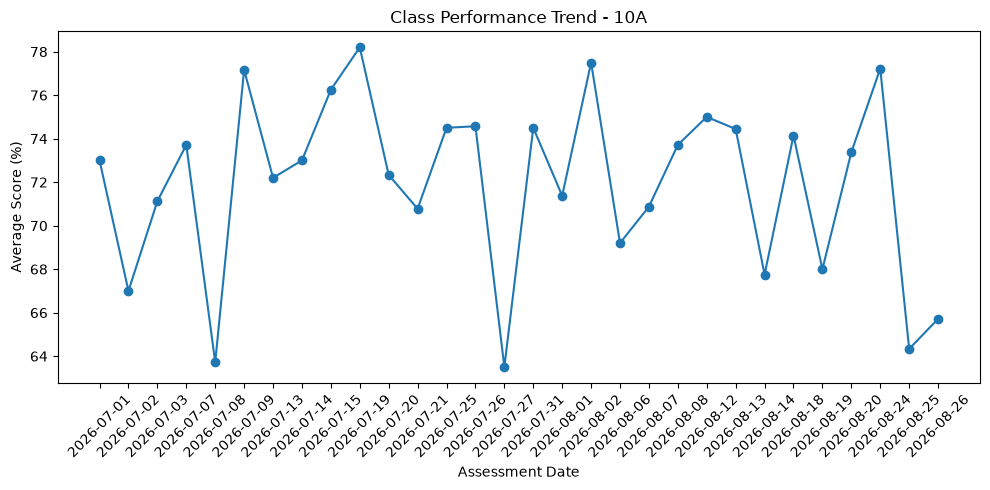

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    class_daily_performance.index,
    class_daily_performance.values,
    marker="o"
)

plt.xlabel("Assessment Date")
plt.ylabel("Average Score (%)")
plt.title(f"Class Performance Trend - {class_id}")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
class_insight = {
    "class_id": class_id,
    "class_average": round(class_average, 2),
    "class_accuracy": round(class_accuracy, 2),
    "strongest_subject": class_strongest_subject,
    "weakest_subject": class_weakest_subject,
    "strongest_topics": class_strong_topics.index.tolist(),
    "weakest_topics": class_weak_topics.index.tolist(),
    "earlier_average": round(earlier_class_avg, 2),
    "recent_average": round(recent_class_avg, 2),
    "trend_difference": round(class_trend_difference, 2),
    "trend": class_trend
}

In [ ]:
class_insight

{'class_id': '10A',
 'class_average': np.float64(71.97),
 'class_accuracy': np.float64(71.84),
 'strongest_subject': 'Chemistry',
 'weakest_subject': 'Mathematics',
 'strongest_topics': ['Thermodynamics',
  'Inorganic Chemistry',
  'Operating Systems'],
 'weakest_topics': ['Optics', 'Computer Networks', 'Probability'],
 'earlier_average': np.float64(72.07),
 'recent_average': np.float64(71.81),
 'trend_difference': np.float64(-0.26),
 'trend': 'Stable'}

In [ ]:
pd.DataFrame([class_insight])

,class_id,class_average,class_accuracy,strongest_subject,weakest_subject,strongest_topics,weakest_topics,earlier_average,recent_average,trend_difference,trend
0,10A,71.97,71.84,Chemistry,Mathematics,"[Thermodynamics, Inorganic Chemistry, Operatin...","[Optics, Computer Networks, Probability]",72.07,71.81,-0.26,Stable


In [ ]:
student_features = (
    processed_df
    .groupby("student_id")
    .agg(
        avg_score=("score_percentage", "mean"),
        avg_accuracy=("accuracy", "mean"),
        avg_time_taken=("time_taken", "mean"),
        total_attempts=("assessment_name", "count")
    )
    .reset_index()
)

student_features.head()

,student_id,avg_score,avg_accuracy,avg_time_taken,total_attempts
0,S001,83.222222,83.122908,45.111111,9
1,S002,70.300000,70.523186,44.200000,10
2,S003,73.000000,72.981224,38.200000,10
3,S004,63.777778,63.235501,49.333333,9
4,S005,68.400000,67.993498,38.000000,10


In [ ]:
student_features.shape

(60, 5)

In [ ]:
def calculate_student_trend(student_df):
    student_df = student_df.sort_values("attempt_date")

    midpoint = len(student_df) // 2

    earlier_avg = (
        student_df.iloc[:midpoint]["score_percentage"].mean()
    )

    recent_avg = (
        student_df.iloc[midpoint:]["score_percentage"].mean()
    )

    return recent_avg - earlier_avg

In [ ]:
calculate_student_trend(
    processed_df[
        processed_df["student_id"] == "S001"
    ]
)

np.float64(2.200000000000003)

In [ ]:
trend_values = (
    processed_df
    .groupby("student_id")
    .apply(calculate_student_trend)
)

In [ ]:
trend_values.head()

student_id
S001     2.2
S002   -14.2
S003     1.6
S004    14.0
S005   -12.0
dtype: float64

In [ ]:
trend_df = trend_values.reset_index(
    name="trend_difference"
)

trend_df.head()

,student_id,trend_difference
0,S001,2.2
1,S002,-14.2
2,S003,1.6
3,S004,14.0
4,S005,-12.0


In [ ]:
student_features = student_features.merge(
    trend_df,
    on="student_id",
    how="left"
)

In [ ]:
student_features.head()

,student_id,avg_score,avg_accuracy,avg_time_taken,total_attempts,trend_difference
0,S001,83.222222,83.122908,45.111111,9,2.2
1,S002,70.300000,70.523186,44.200000,10,-14.2
2,S003,73.000000,72.981224,38.200000,10,1.6
3,S004,63.777778,63.235501,49.333333,9,14.0
4,S005,68.400000,67.993498,38.000000,10,-12.0


In [ ]:
def classify_trend(value):

    if value >= 5:
        return "Improving"

    elif value <= -5:
        return "Declining"

    return "Stable"

In [ ]:
student_features["trend"] = (
    student_features["trend_difference"]
    .apply(classify_trend)
)

In [ ]:
student_features[
    [
        "student_id",
        "avg_score",
        "avg_accuracy",
        "trend_difference",
        "trend"
    ]
].head(10)

,student_id,avg_score,avg_accuracy,trend_difference,trend
0,S001,83.222222,83.122908,2.2,Stable
1,S002,70.300000,70.523186,-14.2,Declining
2,S003,73.000000,72.981224,1.6,Stable
3,S004,63.777778,63.235501,14.0,Improving
4,S005,68.400000,67.993498,-12.0,Declining
5,S006,70.000000,70.127905,-16.2,Declining
6,S007,65.000000,64.635082,14.0,Improving
7,S008,65.100000,65.001106,-3.8,Stable
8,S009,83.200000,83.018960,1.2,Stable
9,S010,68.700000,68.406557,-14.2,Declining


In [ ]:
student_features[
    [
        "student_id",
        "avg_score",
        "avg_accuracy",
        "trend_difference",
        "trend"
    ]
].head(20)

,student_id,avg_score,avg_accuracy,trend_difference,trend
0,S001,83.222222,83.122908,2.20,Stable
1,S002,70.300000,70.523186,-14.20,Declining
2,S003,73.000000,72.981224,1.60,Stable
3,S004,63.777778,63.235501,14.00,Improving
4,S005,68.400000,67.993498,-12.00,Declining
5,S006,70.000000,70.127905,-16.20,Declining
6,S007,65.000000,64.635082,14.00,Improving
7,S008,65.100000,65.001106,-3.80,Stable
8,S009,83.200000,83.018960,1.20,Stable
9,S010,68.700000,68.406557,-14.20,Declining


In [ ]:
student_features["trend"].value_counts()

trend
Stable       24
Improving    19
Declining    17
Name: count, dtype: int64

In [ ]:
student_features[
    [
        "avg_score",
        "avg_accuracy",
        "avg_time_taken",
        "total_attempts",
        "trend_difference"
    ]
].corr()

,avg_score,avg_accuracy,avg_time_taken,total_attempts,trend_difference
avg_score,1.000000,0.999361,-0.169157,0.043340,-0.059209
avg_accuracy,0.999361,1.000000,-0.167013,0.041071,-0.058082
avg_time_taken,-0.169157,-0.167013,1.000000,0.118268,0.169966
total_attempts,0.043340,0.041071,0.118268,1.000000,0.041660
trend_difference,-0.059209,-0.058082,0.169966,0.041660,1.000000


In [ ]:
def assign_risk_label(row):
    
    if (
        row["avg_score"] < 50
        or row["avg_accuracy"] < 50
        or row["trend_difference"] <= -5
    ):
        return 1
    
    return 0

In [ ]:
student_features["risk_label"] = (
    student_features.apply(
        assign_risk_label,
        axis=1
    )
)

In [ ]:
student_features.head()

,student_id,avg_score,avg_accuracy,avg_time_taken,total_attempts,trend_difference,trend,risk_label
0,S001,83.222222,83.122908,45.111111,9,2.2,Stable,0
1,S002,70.300000,70.523186,44.200000,10,-14.2,Declining,1
2,S003,73.000000,72.981224,38.200000,10,1.6,Stable,0
3,S004,63.777778,63.235501,49.333333,9,14.0,Improving,0
4,S005,68.400000,67.993498,38.000000,10,-12.0,Declining,1


In [ ]:
student_features["risk_label"].value_counts()

risk_label
0    43
1    17
Name: count, dtype: int64

In [ ]:
risk_distribution = (
    student_features["risk_label"]
    .value_counts(normalize=True)
    * 100
)

risk_distribution

risk_label
0    71.666667
1    28.333333
Name: proportion, dtype: float64

In [ ]:
student_features["risk_status"] = (
    student_features["risk_label"]
    .map({
        0: "Not At Risk",
        1: "At Risk"
    })
)

In [ ]:
student_features[
    [
        "student_id",
        "avg_score",
        "avg_accuracy",
        "trend_difference",
        "risk_status"
    ]
].head(10)

,student_id,avg_score,avg_accuracy,trend_difference,risk_status
0,S001,83.222222,83.122908,2.2,Not At Risk
1,S002,70.300000,70.523186,-14.2,At Risk
2,S003,73.000000,72.981224,1.6,Not At Risk
3,S004,63.777778,63.235501,14.0,Not At Risk
4,S005,68.400000,67.993498,-12.0,At Risk
5,S006,70.000000,70.127905,-16.2,At Risk
6,S007,65.000000,64.635082,14.0,Not At Risk
7,S008,65.100000,65.001106,-3.8,Not At Risk
8,S009,83.200000,83.018960,1.2,Not At Risk
9,S010,68.700000,68.406557,-14.2,At Risk


In [ ]:
at_risk_students = student_features[
    student_features["risk_label"] == 1
]

at_risk_students

,student_id,avg_score,avg_accuracy,avg_time_taken,total_attempts,trend_difference,trend,risk_label,risk_status
1,S002,70.300000,70.523186,44.200000,10,-14.20,Declining,1,At Risk
4,S005,68.400000,67.993498,38.000000,10,-12.00,Declining,1,At Risk
5,S006,70.000000,70.127905,43.888889,9,-16.20,Declining,1,At Risk
9,S010,68.700000,68.406557,40.900000,10,-14.20,Declining,1,At Risk
17,S018,66.777778,66.645466,41.777778,9,-10.75,Declining,1,At Risk
20,S021,67.900000,67.603330,41.700000,10,-14.60,Declining,1,At Risk
22,S023,64.600000,64.258856,45.300000,10,-7.20,Declining,1,At Risk
23,S024,68.900000,69.012393,45.300000,10,-13.80,Declining,1,At Risk
25,S026,68.000000,67.812732,45.500000,10,-17.60,Declining,1,At Risk
28,S029,65.222222,65.710574,43.333333,9,-14.00,Declining,1,At Risk


In [ ]:
student_features.groupby(
    "risk_status"
)[
    [
        "avg_score",
        "avg_accuracy",
        "avg_time_taken",
        "trend_difference"
    ]
].mean()

,avg_score,avg_accuracy,avg_time_taken,trend_difference
risk_status,,,,
At Risk,67.981699,67.986517,42.650327,-14.473529
Not At Risk,72.911111,72.896762,43.624031,5.926744


In [ ]:
feature_columns = [
    "avg_score",
    "avg_accuracy",
    "avg_time_taken",
    "total_attempts",
    "trend_difference"
]

X = student_features[feature_columns]
y = student_features["risk_label"]

In [ ]:
X.head()

,avg_score,avg_accuracy,avg_time_taken,total_attempts,trend_difference
0,83.222222,83.122908,45.111111,9,2.2
1,70.300000,70.523186,44.200000,10,-14.2
2,73.000000,72.981224,38.200000,10,1.6
3,63.777778,63.235501,49.333333,9,14.0
4,68.400000,67.993498,38.000000,10,-12.0


In [ ]:
y.head()

0    0
1    1
2    0
3    0
4    1
Name: risk_label, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (48, 5)
X_test: (12, 5)
y_train: (48,)
y_test: (12,)


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [ ]:
model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred

array([0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0])

In [ ]:
y_test.values

array([0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0])

In [ ]:
comparison = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred
})

comparison

,actual,predicted
0,0,0
1,1,1
2,0,1
3,0,0
4,0,0
5,0,0
6,1,1
7,0,0
8,0,0
9,0,0


In [ ]:
y_probability = model.predict_proba(X_test)

In [ ]:
y_probability[:5]

array([[9.99999837e-01, 1.62956482e-07],
       [1.97619036e-04, 9.99802381e-01],
       [4.76204765e-01, 5.23795235e-01],
       [9.99999773e-01, 2.27177637e-07],
       [9.99999995e-01, 5.08341149e-09]])

In [ ]:
risk_probability = model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.917


In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")

Precision: 0.750
Recall:    1.000
F1 Score:  0.857


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[8, 1],
       [0, 3]])

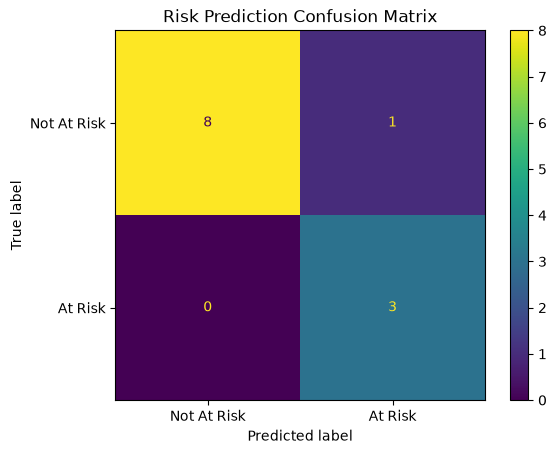

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Not At Risk",
        "At Risk"
    ]
).plot()

plt.title("Risk Prediction Confusion Matrix")
plt.show()

In [ ]:
coefficients = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": model.coef_[0]
})

coefficients.sort_values(
    "coefficient",
    ascending=False
)

,feature,coefficient
3,total_attempts,-0.018484
2,avg_time_taken,-0.024035
0,avg_score,-0.219007
1,avg_accuracy,-0.263825
4,trend_difference,-0.957270


In [ ]:
final_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [ ]:
final_model.fit(
    X,
    y
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [ ]:
student_features["risk_probability"] = (
    final_model.predict_proba(X)[:, 1]
)

In [ ]:
student_features[
    [
        "student_id",
        "avg_score",
        "avg_accuracy",
        "trend_difference",
        "risk_probability"
    ]
].head(10)

,student_id,avg_score,avg_accuracy,trend_difference,risk_probability
0,S001,83.222222,83.122908,2.2,8.425218e-06
1,S002,70.300000,70.523186,-14.2,9.994280e-01
2,S003,73.000000,72.981224,1.6,4.614999e-05
3,S004,63.777778,63.235501,14.0,8.536122e-10
4,S005,68.400000,67.993498,-12.0,9.938383e-01
5,S006,70.000000,70.127905,-16.2,9.999324e-01
6,S007,65.000000,64.635082,14.0,4.617340e-10
7,S008,65.100000,65.001106,-3.8,7.032840e-02
8,S009,83.200000,83.018960,1.2,1.356049e-05
9,S010,68.700000,68.406557,-14.2,9.994697e-01


In [ ]:
def get_risk_level(probability):

    if probability >= 0.70:
        return "High"

    elif probability >= 0.40:
        return "Medium"

    else:
        return "Low"

In [ ]:
student_features["risk_level"] = (
    student_features["risk_probability"]
    .apply(get_risk_level)
)

In [ ]:
student_features[
    [
        "student_id",
        "avg_score",
        "trend_difference",
        "risk_probability",
        "risk_level"
    ]
].head(10)

,student_id,avg_score,trend_difference,risk_probability,risk_level
0,S001,83.222222,2.2,8.425218e-06,Low
1,S002,70.300000,-14.2,9.994280e-01,High
2,S003,73.000000,1.6,4.614999e-05,Low
3,S004,63.777778,14.0,8.536122e-10,Low
4,S005,68.400000,-12.0,9.938383e-01,High
5,S006,70.000000,-16.2,9.999324e-01,High
6,S007,65.000000,14.0,4.617340e-10,Low
7,S008,65.100000,-3.8,7.032840e-02,Low
8,S009,83.200000,1.2,1.356049e-05,Low
9,S010,68.700000,-14.2,9.994697e-01,High


In [ ]:
student_features["risk_level"].value_counts()

risk_level
Low     43
High    17
Name: count, dtype: int64

In [ ]:
high_risk_students = (
    student_features
    .sort_values(
        "risk_probability",
        ascending=False
    )
)

In [ ]:
high_risk_students[
    [
        "student_id",
        "avg_score",
        "avg_accuracy",
        "trend_difference",
        "risk_probability",
        "risk_level"
    ]
].head(10)

,student_id,avg_score,avg_accuracy,trend_difference,risk_probability,risk_level
54,S055,69.555556,69.241172,-19.25,0.999997,High
33,S034,69.400000,69.355012,-19.20,0.999997,High
44,S045,66.333333,66.696476,-17.85,0.999992,High
25,S026,68.000000,67.812732,-17.60,0.999990,High
31,S032,68.700000,69.031069,-16.60,0.999957,High
5,S006,70.000000,70.127905,-16.20,0.999932,High
20,S021,67.900000,67.603330,-14.60,0.999708,High
28,S029,65.222222,65.710574,-14.00,0.999637,High
9,S010,68.700000,68.406557,-14.20,0.999470,High
1,S002,70.300000,70.523186,-14.20,0.999428,High


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=4
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=5
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    )
}

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

d:\Internshipp\student-performance-intelligence\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [ ]:
model_results = pd.DataFrame(results)

model_results.sort_values(
    "F1",
    ascending=False
)


,Model,Accuracy,Precision,Recall,F1
1,Decision Tree,1.000000,1.00,1.0,1.000000
2,Random Forest,1.000000,1.00,1.0,1.000000
0,Logistic Regression,0.916667,0.75,1.0,0.857143
3,SVM,0.916667,0.75,1.0,0.857143


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1"
        ]
    )

    cv_results.append({
        "Model": name,

        "Accuracy Mean":
            scores["test_accuracy"].mean(),

        "Accuracy Std":
            scores["test_accuracy"].std(),

        "Precision Mean":
            scores["test_precision"].mean(),

        "Recall Mean":
            scores["test_recall"].mean(),

        "F1 Mean":
            scores["test_f1"].mean(),

        "F1 Std":
            scores["test_f1"].std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.sort_values(
    "F1 Mean",
    ascending=False
)

d:\Internshipp\student-performance-intelligence\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\Internshipp\student-performance-intelligence\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\Internshipp\student-performance-intelligence\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\Internshipp\student-performance-intelligence\.venv\Lib\site-packages\sklearn\svm\_bas

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,F1 Std
0,Logistic Regression,0.983333,0.033333,1.0,0.95,0.971429,0.057143
1,Decision Tree,0.983333,0.033333,1.0,0.95,0.971429,0.057143
2,Random Forest,0.983333,0.033333,1.0,0.95,0.971429,0.057143
3,SVM,0.966667,0.040825,0.9,1.00,0.942857,0.069985


In [ ]:
cv_results_df.sort_values(
    "F1 Mean",
    ascending=False
)

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,F1 Std
0,Logistic Regression,0.983333,0.033333,1.0,0.95,0.971429,0.057143
1,Decision Tree,0.983333,0.033333,1.0,0.95,0.971429,0.057143
2,Random Forest,0.983333,0.033333,1.0,0.95,0.971429,0.057143
3,SVM,0.966667,0.040825,0.9,1.00,0.942857,0.069985


In [ ]:
cv_results_df.round(3)

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,F1 Std
0,Logistic Regression,0.983,0.033,1.0,0.95,0.971,0.057
1,Decision Tree,0.983,0.033,1.0,0.95,0.971,0.057
2,Random Forest,0.983,0.033,1.0,0.95,0.971,0.057
3,SVM,0.967,0.041,0.9,1.00,0.943,0.070


In [ ]:
cv_results_df[
    [
        "Model",
        "F1 Mean",
        "F1 Std"
    ]
].sort_values(
    "F1 Mean",
    ascending=False
)

,Model,F1 Mean,F1 Std
0,Logistic Regression,0.971429,0.057143
1,Decision Tree,0.971429,0.057143
2,Random Forest,0.971429,0.057143
3,SVM,0.942857,0.069985


In [ ]:
cv_results_df[
    [
        "Model",
        "Recall Mean"
    ]
].sort_values(
    "Recall Mean",
    ascending=False
)

,Model,Recall Mean
3,SVM,1.00
0,Logistic Regression,0.95
1,Decision Tree,0.95
2,Random Forest,0.95


In [ ]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():

    f1_scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="f1"
    )

    print(f"\n{name}")
    print("Fold F1 scores:", f1_scores.round(3))
    print("Mean F1:", f1_scores.mean().round(3))


Logistic Regression
Fold F1 scores: [1.    1.    1.    1.    0.857]
Mean F1: 0.971

Decision Tree
Fold F1 scores: [1.    1.    1.    1.    0.857]
Mean F1: 0.971

Random Forest
Fold F1 scores: [1.    1.    1.    1.    0.857]
Mean F1: 0.971

SVM
Fold F1 scores: [0.857 1.    0.857 1.    1.   ]
Mean F1: 0.943


d:\Internshipp\student-performance-intelligence\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\Internshipp\student-performance-intelligence\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\Internshipp\student-performance-intelligence\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\Internshipp\student-performance-intelligence\.venv\Lib\site-packages\sklearn\svm\_bas

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
scaled_logistic = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        )
    )
])

In [ ]:
scaled_scores = cross_validate(
    scaled_logistic,
    X,
    y,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1"
    ]
)

In [ ]:
scaled_results = {
    "Accuracy Mean": scaled_scores[
        "test_accuracy"
    ].mean(),

    "Precision Mean": scaled_scores[
        "test_precision"
    ].mean(),

    "Recall Mean": scaled_scores[
        "test_recall"
    ].mean(),

    "F1 Mean": scaled_scores[
        "test_f1"
    ].mean()
}

pd.DataFrame(
    [scaled_results]
).round(3)

,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean
0,0.95,0.95,0.9,0.905


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (Original)",
        "Logistic Regression (Scaled)"
    ],
    "Accuracy": [
        cv_results_df.loc[
            cv_results_df["Model"] == "Logistic Regression",
            "Accuracy Mean"
        ].iloc[0],
        scaled_results["Accuracy Mean"]
    ],
    "Precision": [
        cv_results_df.loc[
            cv_results_df["Model"] == "Logistic Regression",
            "Precision Mean"
        ].iloc[0],
        scaled_results["Precision Mean"]
    ],
    "Recall": [
        cv_results_df.loc[
            cv_results_df["Model"] == "Logistic Regression",
            "Recall Mean"
        ].iloc[0],
        scaled_results["Recall Mean"]
    ],
    "F1": [
        cv_results_df.loc[
            cv_results_df["Model"] == "Logistic Regression",
            "F1 Mean"
        ].iloc[0],
        scaled_results["F1 Mean"]
    ]
})

comparison.round(3)

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression (Original),0.983,1.00,0.95,0.971
1,Logistic Regression (Scaled),0.950,0.95,0.90,0.905


In [ ]:
final_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [ ]:
final_model.fit(X, y)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [ ]:
student_features["risk_probability"] = (
    final_model.predict_proba(X)[:, 1]
)

In [ ]:
student_features[
    [
        "student_id",
        "avg_score",
        "avg_accuracy",
        "trend_difference",
        "risk_probability"
    ]
].head(10)

,student_id,avg_score,avg_accuracy,trend_difference,risk_probability
0,S001,83.222222,83.122908,2.2,8.425218e-06
1,S002,70.300000,70.523186,-14.2,9.994280e-01
2,S003,73.000000,72.981224,1.6,4.614999e-05
3,S004,63.777778,63.235501,14.0,8.536122e-10
4,S005,68.400000,67.993498,-12.0,9.938383e-01
5,S006,70.000000,70.127905,-16.2,9.999324e-01
6,S007,65.000000,64.635082,14.0,4.617340e-10
7,S008,65.100000,65.001106,-3.8,7.032840e-02
8,S009,83.200000,83.018960,1.2,1.356049e-05
9,S010,68.700000,68.406557,-14.2,9.994697e-01


In [ ]:
def get_risk_level(probability):

    if probability >= 0.70:
        return "High"

    elif probability >= 0.40:
        return "Medium"

    return "Low"

In [ ]:
student_features["risk_level"] = (
    student_features["risk_probability"]
    .apply(get_risk_level)
)

In [ ]:
student_features[
    [
        "student_id",
        "risk_probability",
        "risk_level"
    ]
].head(10)

,student_id,risk_probability,risk_level
0,S001,8.425218e-06,Low
1,S002,9.994280e-01,High
2,S003,4.614999e-05,Low
3,S004,8.536122e-10,Low
4,S005,9.938383e-01,High
5,S006,9.999324e-01,High
6,S007,4.617340e-10,Low
7,S008,7.032840e-02,Low
8,S009,1.356049e-05,Low
9,S010,9.994697e-01,High


In [ ]:
import joblib

In [ ]:
joblib.dump(
    final_model,
    "../ml/risk_model.pkl"
)

['../ml/risk_model.pkl']

In [ ]:
loaded_model = joblib.load(
    "../ml/risk_model.pkl"
)

In [ ]:
loaded_predictions = loaded_model.predict(X)

(
    loaded_predictions
    == final_model.predict(X)
).all()

np.True_

In [ ]:
student_id = "S001"

In [ ]:
student_df = processed_df[
    processed_df["student_id"] == student_id
].copy()

student_df = student_df.sort_values(
    "attempt_date"
)

In [ ]:
student_ml = student_features[
    student_features["student_id"] == student_id
].iloc[0]

In [ ]:
student_ml

student_id                 S001
avg_score             83.222222
avg_accuracy          83.122908
avg_time_taken        45.111111
total_attempts                9
trend_difference            2.2
trend                    Stable
risk_label                    0
risk_status         Not At Risk
risk_probability       0.000008
risk_level                  Low
Name: 0, dtype: object

In [ ]:
llm_input = {
    "student": {
        "student_id": student_id,
        "student_name": student_df["student_name"].iloc[0],
        "class_id": student_df["class_id"].iloc[0]
    },

    "performance": {
        "overall_score": round(
            student_ml["avg_score"], 2
        ),
        "overall_accuracy": round(
            student_ml["avg_accuracy"], 2
        ),
        "average_time_taken": round(
            student_ml["avg_time_taken"], 2
        ),
        "total_assessments": int(
            student_ml["total_attempts"]
        )
    },

    "strengths": {
        "strongest_subject": strongest_subject,
        "strongest_topic": strongest_topic
    },

    "weaknesses": {
        "weakest_subject": weakest_subject,
        "weakest_topic": weakest_topic
    },

    "trend": {
        "earlier_average": round(
            earlier_avg, 2
        ),
        "recent_average": round(
            recent_avg, 2
        ),
        "difference": round(
            student_ml["trend_difference"], 2
        ),
        "status": student_ml["trend"]
    },

    "risk": {
        "probability": round(
            student_ml["risk_probability"], 3
        ),
        "level": student_ml["risk_level"]
    }
}

In [ ]:
import json

print(
    json.dumps(
        llm_input,
        indent=4
    )
)

{
    "student": {
        "student_id": "S001",
        "student_name": "Aarav",
        "class_id": "10A"
    },
    "performance": {
        "overall_score": 83.22,
        "overall_accuracy": 83.12,
        "average_time_taken": 45.11,
        "total_assessments": 9
    },
    "strengths": {
        "strongest_subject": "Physics",
        "strongest_topic": "Organic Chemistry"
    },
    "weaknesses": {
        "weakest_subject": "Mathematics",
        "weakest_topic": "Probability"
    },
    "trend": {
        "earlier_average": 70.2,
        "recent_average": 72.6,
        "difference": 2.2,
        "status": "Stable"
    },
    "risk": {
        "probability": 0.0,
        "level": "Low"
    }
}


In [ ]:
llm_prompt = f"""
You are an AI academic performance assistant.

Analyze the following structured student performance data.

Student data:
{json.dumps(llm_input, indent=2)}

Provide your response in exactly this JSON structure:

{{
    "summary": "A concise 2-3 sentence summary of the student's performance.",
    "explanation": "Explain the main strengths, weaknesses, performance trend, and risk level using the provided data.",
    "recommendation": "Give 2-3 specific and actionable recommendations based only on the provided data."
}}

Rules:
- Do not invent any scores, topics, or facts.
- Do not recalculate metrics.
- Use only the provided student data.
- Keep the recommendations practical and specific.
- Return valid JSON only.
"""

In [ ]:
print(llm_prompt)


You are an AI academic performance assistant.

Analyze the following structured student performance data.

Student data:
{
  "student": {
    "student_id": "S001",
    "student_name": "Aarav",
    "class_id": "10A"
  },
  "performance": {
    "overall_score": 83.22,
    "overall_accuracy": 83.12,
    "average_time_taken": 45.11,
    "total_assessments": 9
  },
  "strengths": {
    "strongest_subject": "Physics",
    "strongest_topic": "Organic Chemistry"
  },
  "weaknesses": {
    "weakest_subject": "Mathematics",
    "weakest_topic": "Probability"
  },
  "trend": {
    "earlier_average": 70.2,
    "recent_average": 72.6,
    "difference": 2.2,
    "status": "Stable"
  },
  "risk": {
    "probability": 0.0,
    "level": "Low"
  }
}

Provide your response in exactly this JSON structure:

{
    "summary": "A concise 2-3 sentence summary of the student's performance.",
    "explanation": "Explain the main strengths, weaknesses, performance trend, and risk level using the provided data.",

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")

print(
    "API key loaded:",
    groq_api_key is not None
)

API key loaded: True


In [ ]:
from groq import Groq

client = Groq(
    api_key=groq_api_key
)

In [ ]:
response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[
        {
            "role": "user",
            "content": "Reply with exactly: Groq connection successful."
        }
    ],
    temperature=0
)

AuthenticationError: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}

In [ ]:
print("API key exists:", groq_api_key is not None)
print("API key length:", len(groq_api_key) if groq_api_key else 0)

API key exists: True
API key length: 24


In [ ]:
from pathlib import Path
from dotenv import load_dotenv
import os

PROJECT_ROOT = Path.cwd().parent

load_dotenv(PROJECT_ROOT / ".env")

groq_api_key = os.getenv("GROQ_API_KEY")

print("API key exists:", groq_api_key is not None)
print("API key length:", len(groq_api_key) if groq_api_key else 0)

API key exists: True
API key length: 24


In [ ]:
print(groq_api_key[:7])

your_ac


In [ ]:
from dotenv import load_dotenv
import os

load_dotenv(override=True)

groq_api_key = os.getenv("GROQ_API_KEY")

print("API key exists:", groq_api_key is not None)
print("API key length:", len(groq_api_key) if groq_api_key else 0)
print("Prefix:", groq_api_key[:7] if groq_api_key else None)

API key exists: True
API key length: 56
Prefix: gsk_jfR


In [ ]:
from groq import Groq

client = Groq(
    api_key=groq_api_key
)

In [ ]:
response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[
        {
            "role": "user",
            "content": "Reply with exactly: Groq connection successful."
        }
    ],
    temperature=0
)

print(response.choices[0].message.content)

Groq connection successful.


In [ ]:
print(json.dumps(llm_input, indent=2))

{
  "student": {
    "student_id": "S001",
    "student_name": "Aarav",
    "class_id": "10A"
  },
  "performance": {
    "overall_score": 83.22,
    "overall_accuracy": 83.12,
    "average_time_taken": 45.11,
    "total_assessments": 9
  },
  "strengths": {
    "strongest_subject": "Physics",
    "strongest_topic": "Organic Chemistry"
  },
  "weaknesses": {
    "weakest_subject": "Mathematics",
    "weakest_topic": "Probability"
  },
  "trend": {
    "earlier_average": 70.2,
    "recent_average": 72.6,
    "difference": 2.2,
    "status": "Stable"
  },
  "risk": {
    "probability": 0.0,
    "level": "Low"
  }
}


In [ ]:
response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[
        {
            "role": "system",
            "content": (
                "You are an AI academic performance assistant. "
                "Return valid JSON only."
            )
        },
        {
            "role": "user",
            "content": llm_prompt
        }
    ],
    temperature=0.2
)

In [ ]:
llm_output = response.choices[0].message.content

print(llm_output)

```
{
    "summary": "Aarav, a student in class 10A, has an overall score of 83.22 and shows stability in performance with a recent average of 72.6. The student excels in Physics and Organic Chemistry but struggles with Mathematics and Probability. Aarav is currently at low risk.",
    "explanation": "Aarav's strongest subject is Physics, and within that, Organic Chemistry is a particular area of strength. However, the student's weakest subject is Mathematics, with a notable struggle in Probability. The performance trend indicates a stable status with a slight improvement from an earlier average of 70.2 to a recent average of 72.6, and the risk level is classified as low with a probability of 0.0.",
    "recommendation": "To further improve, Aarav should focus on practicing Mathematics, especially Probability, to address the weakness. The student could also explore additional resources or tutoring in Mathematics to support learning. Additionally, Aarav should continue to build on the s

In [ ]:
import json

try:
    insight = json.loads(llm_output)
    print("Valid JSON")
    print(insight)

except json.JSONDecodeError:
    print("Invalid JSON returned by LLM")

Invalid JSON returned by LLM


In [ ]:
print(llm_output)

```
{
    "summary": "Aarav, a student in class 10A, has an overall score of 83.22 and shows stability in performance with a recent average of 72.6. The student excels in Physics and Organic Chemistry but struggles with Mathematics and Probability. Aarav is currently at low risk.",
    "explanation": "Aarav's strongest subject is Physics, and within that, Organic Chemistry is a particular area of strength. However, the student's weakest subject is Mathematics, with a notable struggle in Probability. The performance trend indicates a stable status with a slight improvement from an earlier average of 70.2 to a recent average of 72.6, and the risk level is classified as low with a probability of 0.0.",
    "recommendation": "To further improve, Aarav should focus on practicing Mathematics, especially Probability, to address the weakness. The student could also explore additional resources or tutoring in Mathematics to support learning. Additionally, Aarav should continue to build on the s

In [ ]:
print(repr(llm_output))

'```\n{\n    "summary": "Aarav, a student in class 10A, has an overall score of 83.22 and shows stability in performance with a recent average of 72.6. The student excels in Physics and Organic Chemistry but struggles with Mathematics and Probability. Aarav is currently at low risk.",\n    "explanation": "Aarav\'s strongest subject is Physics, and within that, Organic Chemistry is a particular area of strength. However, the student\'s weakest subject is Mathematics, with a notable struggle in Probability. The performance trend indicates a stable status with a slight improvement from an earlier average of 70.2 to a recent average of 72.6, and the risk level is classified as low with a probability of 0.0.",\n    "recommendation": "To further improve, Aarav should focus on practicing Mathematics, especially Probability, to address the weakness. The student could also explore additional resources or tutoring in Mathematics to support learning. Additionally, Aarav should continue to build o

In [ ]:
import json

clean_output = llm_output.strip()

# Remove markdown/code formatting if the LLM adds it
clean_output = clean_output.strip("`").strip()

insight = json.loads(clean_output)

print("Valid JSON")
print(insight)

Valid JSON
{'summary': 'Aarav, a student in class 10A, has an overall score of 83.22 and shows stability in performance with a recent average of 72.6. The student excels in Physics and Organic Chemistry but struggles with Mathematics and Probability. Aarav is currently at low risk.', 'explanation': "Aarav's strongest subject is Physics, and within that, Organic Chemistry is a particular area of strength. However, the student's weakest subject is Mathematics, with a notable struggle in Probability. The performance trend indicates a stable status with a slight improvement from an earlier average of 70.2 to a recent average of 72.6, and the risk level is classified as low with a probability of 0.0.", 'recommendation': 'To further improve, Aarav should focus on practicing Mathematics, especially Probability, to address the weakness. The student could also explore additional resources or tutoring in Mathematics to support learning. Additionally, Aarav should continue to build on the strengt

In [ ]:
print(json.dumps(llm_input, indent=4))

{
    "student": {
        "student_id": "S001",
        "student_name": "Aarav",
        "class_id": "10A"
    },
    "performance": {
        "overall_score": 83.22,
        "overall_accuracy": 83.12,
        "average_time_taken": 45.11,
        "total_assessments": 9
    },
    "strengths": {
        "strongest_subject": "Physics",
        "strongest_topic": "Organic Chemistry"
    },
    "weaknesses": {
        "weakest_subject": "Mathematics",
        "weakest_topic": "Probability"
    },
    "trend": {
        "earlier_average": 70.2,
        "recent_average": 72.6,
        "difference": 2.2,
        "status": "Stable"
    },
    "risk": {
        "probability": 0.0,
        "level": "Low"
    }
}


In [ ]:
print("Student:", llm_input["student"])
print("Performance:", llm_input["performance"])
print("Strengths:", llm_input["strengths"])
print("Weaknesses:", llm_input["weaknesses"])
print("Trend:", llm_input["trend"])
print("Risk:", llm_input["risk"])

Student: {'student_id': 'S001', 'student_name': 'Aarav', 'class_id': '10A'}
Performance: {'overall_score': np.float64(83.22), 'overall_accuracy': np.float64(83.12), 'average_time_taken': np.float64(45.11), 'total_assessments': 9}
Strengths: {'strongest_subject': 'Physics', 'strongest_topic': 'Organic Chemistry'}
Weaknesses: {'weakest_subject': 'Mathematics', 'weakest_topic': 'Probability'}
Trend: {'earlier_average': np.float64(70.2), 'recent_average': np.float64(72.6), 'difference': np.float64(2.2), 'status': 'Stable'}
Risk: {'probability': np.float64(0.0), 'level': 'Low'}


In [ ]:
def generate_fallback_insight(llm_input):
    
    student_name = llm_input["student"]["student_name"]
    
    overall_score = llm_input["performance"]["overall_score"]
    accuracy = llm_input["performance"]["overall_accuracy"]
    
    strongest_subject = (
        llm_input["strengths"]["strongest_subject"]
    )
    
    strongest_topic = (
        llm_input["strengths"]["strongest_topic"]
    )
    
    weakest_subject = (
        llm_input["weaknesses"]["weakest_subject"]
    )
    
    weakest_topic = (
        llm_input["weaknesses"]["weakest_topic"]
    )
    
    trend = llm_input["trend"]["status"]
    
    risk_level = llm_input["risk"]["level"]
    
    risk_probability = (
        llm_input["risk"]["probability"]
    )

    # Summary
    summary = (
        f"{student_name} has an overall score of "
        f"{overall_score:.2f}% with an accuracy of "
        f"{accuracy:.2f}%. The current performance trend "
        f"is {trend.lower()} and the predicted risk level "
        f"is {risk_level.lower()}."
    )

    # Explanation
    explanation = (
        f"The student's strongest subject is "
        f"{strongest_subject}, with {strongest_topic} "
        f"being the strongest topic. The main area requiring "
        f"attention is {weakest_subject}, particularly "
        f"{weakest_topic}. The predicted risk probability "
        f"is {risk_probability:.2f}."
    )

    # Recommendation
    recommendation = (
        f"Focus on improving {weakest_topic} within "
        f"{weakest_subject}. Continue practicing the weaker "
        f"areas while maintaining the current strengths in "
        f"{strongest_subject} and {strongest_topic}."
    )

    return {
        "summary": summary,
        "explanation": explanation,
        "recommendation": recommendation
    }

In [ ]:
fallback_insight = generate_fallback_insight(
    llm_input
)

In [ ]:
print(
    json.dumps(
        fallback_insight,
        indent=4
    )
)

{
    "summary": "Aarav has an overall score of 83.22% with an accuracy of 83.12%. The current performance trend is stable and the predicted risk level is low.",
    "explanation": "The student's strongest subject is Physics, with Organic Chemistry being the strongest topic. The main area requiring attention is Mathematics, particularly Probability. The predicted risk probability is 0.00.",
    "recommendation": "Focus on improving Probability within Mathematics. Continue practicing the weaker areas while maintaining the current strengths in Physics and Organic Chemistry."
}


In [ ]:
def generate_ai_insight(llm_input):
    
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {
                    "role": "system",
                    "content": (
                        "You are an AI academic performance "
                        "assistant. Return valid JSON only."
                    )
                },
                {
                    "role": "user",
                    "content": f"""
Analyze the following structured student performance data.

{json.dumps(llm_input, indent=2)}

Return exactly this JSON structure:

{{
    "summary": "...",
    "explanation": "...",
    "recommendation": "..."
}}

Rules:
- Use only the provided data.
- Do not invent facts.
- Do not recalculate metrics.
- Keep recommendations actionable.
- Return JSON only.
"""
                }
            ],
            temperature=0.2
        )

        raw_output = (
            response
            .choices[0]
            .message
            .content
            .strip()
        )

        # Remove possible markdown/backtick formatting
        raw_output = raw_output.strip("`").strip()

        insight = json.loads(raw_output)

        return {
            "source": "llm",
            "insight": insight
        }

    except Exception as e:

        print(
            f"LLM generation failed: {e}"
        )

        return {
            "source": "fallback",
            "insight": generate_fallback_insight(
                llm_input
            )
        }

In [ ]:
ai_result = generate_ai_insight(
    llm_input
)

In [ ]:
print(
    json.dumps(
        ai_result,
        indent=4
    )
)

{
    "source": "llm",
    "insight": {
        "summary": "Aarav, a student in class 10A, has an overall score of 83.22 and is performing well, with a stable trend and low risk of decline.",
        "explanation": "Aarav's strengths lie in Physics and Organic Chemistry, while weaknesses are in Mathematics and Probability. The student's recent average score is 72.6, showing a stable trend with a difference of 2.2 from the earlier average.",
        "recommendation": "Focus on improving Mathematics and Probability skills to further enhance overall performance."
    }
}


In [ ]:
class FakeClient:

    class Chat:

        class Completions:

            def create(self, *args, **kwargs):
                raise Exception(
                    "Simulated API failure"
                )

        completions = Completions()

    chat = Chat()

In [ ]:
original_client = client

client = FakeClient()

In [ ]:
fallback_test = generate_ai_insight(
    llm_input
)

LLM generation failed: Simulated API failure


In [ ]:
print(
    json.dumps(
        fallback_test,
        indent=4
    )
)

{
    "source": "fallback",
    "insight": {
        "summary": "Aarav has an overall score of 83.22% with an accuracy of 83.12%. The current performance trend is stable and the predicted risk level is low.",
        "explanation": "The student's strongest subject is Physics, with Organic Chemistry being the strongest topic. The main area requiring attention is Mathematics, particularly Probability. The predicted risk probability is 0.00.",
        "recommendation": "Focus on improving Probability within Mathematics. Continue practicing the weaker areas while maintaining the current strengths in Physics and Organic Chemistry."
    }
}


In [ ]:
client = original_client

In [ ]:
from llm.insight_generator import (
    generate_ai_insight
)

ModuleNotFoundError: No module named 'llm'

In [ ]:
from llm.insight_generator import generate_ai_insight

ModuleNotFoundError: No module named 'llm'

In [ ]:
import os

print(os.getcwd())

d:\Internshipp\student-performance-intelligence\notebooks


In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [ ]:
from llm.insight_generator import generate_ai_insight

In [ ]:
ai_result = generate_ai_insight(
    llm_input
)

In [ ]:
import json

print(
    json.dumps(
        ai_result,
        indent=4
    )
)

{
    "source": "llm",
    "insight": {
        "summary": "Aarav, a student in class 10A, has an overall score of 83.22 and is performing strongest in Physics and Organic Chemistry, but weakest in Mathematics and Probability.",
        "explanation": "The student's performance trend is stable, with a recent average score of 72.6, which is 2.2 points higher than the earlier average. The risk of underperformance is low.",
        "recommendation": "Focus on improving Mathematics and Probability skills to complement existing strengths in Physics and Organic Chemistry."
    }
}


In [ ]:
from analytics.student_analysis import (
    get_student_analysis
)

In [ ]:
student_result = get_student_analysis(
    student_id,
    processed_df,
    student_features
)

In [ ]:
print(
    json.dumps(
        student_result,
        indent=4
    )
)

{
    "student_id": "S001",
    "student_name": "Aarav",
    "class_id": "10A",
    "overall_score": 83.22,
    "overall_accuracy": 83.12,
    "strongest_subject": "Computer Science",
    "weakest_subject": "Chemistry",
    "strongest_topic": "Data Structures",
    "weakest_topic": "Inorganic Chemistry",
    "trend": "Stable",
    "trend_difference": 2.2,
    "risk_probability": 0.0,
    "risk_level": "Low"
}


In [ ]:
from analytics.class_analysis import (
    get_class_analysis
)

In [ ]:
class_id = "10A"

In [ ]:
class_result = get_class_analysis(
    class_id,
    processed_df
)

In [ ]:
print(class_result)

{'class_id': '10A', 'class_average': np.float64(71.97), 'class_accuracy': np.float64(71.84), 'strongest_subject': 'Chemistry', 'weakest_subject': 'Mathematics', 'strongest_topics': ['Thermodynamics', 'Inorganic Chemistry', 'Operating Systems'], 'weakest_topics': ['Optics', 'Computer Networks', 'Probability'], 'earlier_average': np.float64(72.07), 'recent_average': np.float64(71.81), 'trend_difference': np.float64(-0.26), 'trend': 'Stable', 'student_count': 20}


In [ ]:
print("Class average:")
print(class_result["class_average"])

print("\nClass accuracy:")
print(class_result["class_accuracy"])

print("\nStrongest subject:")
print(class_result["strongest_subject"])

print("\nWeakest subject:")
print(class_result["weakest_subject"])

print("\nTrend:")
print(class_result["trend"])

Class average:
71.97

Class accuracy:
71.84

Strongest subject:
Chemistry

Weakest subject:
Mathematics

Trend:
Stable


In [ ]:
from analytics.trend_analysis import (
    calculate_trend_difference
)

In [ ]:
student_scores = (
    student_df
    .sort_values("attempt_date")[
        "score_percentage"
    ]
    .reset_index(drop=True)
)

In [ ]:
student_trend = calculate_trend_difference(
    student_scores
)

In [ ]:
student_trend

{'earlier_average': np.float64(82.0),
 'recent_average': np.float64(84.2),
 'trend_difference': np.float64(2.2),
 'trend': 'Stable'}

In [ ]:
class_daily_scores = (
    processed_df[
        processed_df["class_id"] == "10A"
    ]
    .groupby("attempt_date")[
        "score_percentage"
    ]
    .mean()
    .sort_index()
)

In [ ]:
class_trend = calculate_trend_difference(
    class_daily_scores
)

In [ ]:
class_trend

{'earlier_average': np.float64(72.07),
 'recent_average': np.float64(71.81),
 'trend_difference': np.float64(-0.26),
 'trend': 'Stable'}

In [ ]:
import importlib
import analytics.student_analysis as student_analysis

importlib.reload(student_analysis)

<module 'analytics.student_analysis' from 'd:\\Internshipp\\student-performance-intelligence\\analytics\\student_analysis.py'>

In [ ]:
student_result = student_analysis.get_student_analysis(
    student_id,
    processed_df,
    student_features
)

In [ ]:
print(
    json.dumps(
        student_result,
        indent=4
    )
)

{
    "student_id": "S001",
    "student_name": "Aarav",
    "class_id": "10A",
    "overall_score": 83.22,
    "overall_accuracy": 83.12,
    "strongest_subject": "Computer Science",
    "weakest_subject": "Chemistry",
    "strongest_topic": "Data Structures",
    "weakest_topic": "Inorganic Chemistry",
    "trend": "Stable",
    "trend_difference": 2.2,
    "risk_probability": 0.0,
    "risk_level": "Low"
}


In [ ]:
import analytics.class_analysis as class_analysis

importlib.reload(class_analysis)

<module 'analytics.class_analysis' from 'd:\\Internshipp\\student-performance-intelligence\\analytics\\class_analysis.py'>

In [ ]:
class_result = class_analysis.get_class_analysis(
    class_id,
    processed_df
)

In [ ]:
print(
    json.dumps(
        class_result,
        indent=4
    )
)

{
    "class_id": "10A",
    "class_average": 71.97,
    "class_accuracy": 71.84,
    "strongest_subject": "Chemistry",
    "weakest_subject": "Mathematics",
    "strongest_topics": [
        "Thermodynamics",
        "Inorganic Chemistry",
        "Operating Systems"
    ],
    "weakest_topics": [
        "Optics",
        "Computer Networks",
        "Probability"
    ],
    "earlier_average": 72.07,
    "recent_average": 71.81,
    "trend_difference": -0.26,
    "trend": "Stable",
    "student_count": 20
}


In [ ]:
student_scores = (
    processed_df[
        processed_df["student_id"] == student_id
    ]
    .sort_values("attempt_date")[
        "score_percentage"
    ]
    .reset_index(drop=True)
)

student_trend = calculate_trend_difference(
    student_scores
)

print(student_trend)

{'earlier_average': np.float64(82.0), 'recent_average': np.float64(84.2), 'trend_difference': np.float64(2.2), 'trend': 'Stable'}


In [ ]:
class_daily_scores = (
    processed_df[
        processed_df["class_id"] == class_id
    ]
    .groupby("attempt_date")[
        "score_percentage"
    ]
    .mean()
    .sort_index()
)

class_trend = calculate_trend_difference(
    class_daily_scores
)

print(class_trend)

{'earlier_average': np.float64(72.07), 'recent_average': np.float64(71.81), 'trend_difference': np.float64(-0.26), 'trend': 'Stable'}


In [ ]:
from analytics.processing import (
    load_and_process_data
)

In [ ]:
test_df = load_and_process_data(
    "../data/raw_data.csv"
)

ValueError: time data "2026-99-99" doesn't match format "%Y-%m-%d". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
test_df = load_and_process_data(
    "../data/raw_data.csv"
)

ValueError: time data "2026-99-99" doesn't match format "%Y-%m-%d". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
import importlib
import analytics.processing as processing

importlib.reload(processing)

<module 'analytics.processing' from 'd:\\Internshipp\\student-performance-intelligence\\analytics\\processing.py'>

In [ ]:
test_df = processing.load_and_process_data(
    "../data/raw_data.csv"
)

In [ ]:
print(test_df.shape)

(597, 12)


In [ ]:
print(
    test_df["attempt_date"].isna().sum()
)

0


In [ ]:
from ml.prediction import (
    create_student_features,
    load_risk_model,
    predict_student_risk
)

In [ ]:
ml_test_features = create_student_features(
    processed_df
)

KeyError: "Label(s) ['attempt_id', 'time_taken_seconds'] do not exist"

In [ ]:
processed_df.columns.tolist()

['student_id',
 'student_name',
 'class_id',
 'subject',
 'topic',
 'assessment_name',
 'marks_obtained',
 'total_marks',
 'attempt_date',
 'time_taken',
 'questions_attempted',
 'questions_correct',
 'score_percentage',
 'accuracy']

In [ ]:
print(processed_df.head())

  student_id student_name class_id           subject                topic  \
0       S012          Dev      10A         Chemistry  Inorganic Chemistry   
1       S053      Sarthak      10C       Mathematics              Algebra   
2       S057       Tushar      10C           Physics       Thermodynamics   
3       S008        Kabir      10A  Computer Science    Computer Networks   
4       S019         Isha      10A           Physics  Current Electricity   

  assessment_name  marks_obtained  total_marks attempt_date  time_taken  \
0    Assessment 1              82          100   2026-07-01        32.0   
1    Assessment 8              74          100   2026-08-14        37.0   
2    Assessment 8              74          100   2026-08-13        55.0   
3    Assessment 8              61          100   2026-08-12        26.0   
4    Assessment 2              71          100   2026-07-07        45.0   

   questions_attempted  questions_correct  score_percentage   accuracy  
0            

In [ ]:
for column in processed_df.columns:
    print(column)

student_id
student_name
class_id
subject
topic
assessment_name
marks_obtained
total_marks
attempt_date
time_taken
questions_attempted
questions_correct
score_percentage
accuracy


In [ ]:
import importlib
import ml.prediction as prediction

importlib.reload(prediction)

<module 'ml.prediction' from 'd:\\Internshipp\\student-performance-intelligence\\ml\\prediction.py'>

In [ ]:
ml_test_features = prediction.create_student_features(
    processed_df
)

In [ ]:
ml_test_features.head()

,student_id,avg_score,avg_accuracy,avg_time_taken,total_attempts,trend_difference
0,S001,83.222222,83.122908,45.111111,9,2.2
1,S002,70.300000,70.523186,44.200000,10,-14.2
2,S003,73.000000,72.981224,38.200000,10,1.6
3,S004,63.777778,63.235501,49.333333,9,14.0
4,S005,68.400000,67.993498,38.000000,10,-12.0


In [ ]:
ml_test_features.columns.tolist()

['student_id',
 'avg_score',
 'avg_accuracy',
 'avg_time_taken',
 'total_attempts',
 'trend_difference']

In [ ]:
model = prediction.load_risk_model(
    "../ml/risk_model.pkl"
)

In [ ]:
feature_columns = [
    "avg_score",
    "avg_accuracy",
    "avg_time_taken",
    "total_attempts",
    "trend_difference"
]

In [ ]:
ml_predictions = prediction.predict_student_risk(
    ml_test_features,
    model
)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- total_attempts


In [ ]:
print(model.feature_names_in_)

['avg_score' 'avg_accuracy' 'avg_time_taken' 'total_attempts'
 'trend_difference']


In [ ]:
print("Number of features:", model.n_features_in_)

Number of features: 5


In [ ]:
print(ml_test_features.columns.tolist())

['student_id', 'avg_score', 'avg_accuracy', 'avg_time_taken', 'total_attempts', 'trend_difference']


In [ ]:
import importlib
import ml.prediction as prediction

importlib.reload(prediction)

<module 'ml.prediction' from 'd:\\Internshipp\\student-performance-intelligence\\ml\\prediction.py'>

In [ ]:
print(ml_test_features.columns.tolist())

['student_id', 'avg_score', 'avg_accuracy', 'avg_time_taken', 'total_attempts', 'trend_difference']


In [ ]:
print("Model expects:")
print(model.feature_names_in_)

print("\nPrediction features:")
print([
    "avg_score",
    "avg_accuracy",
    "avg_time_taken",
    "total_attempts",
    "trend_difference"
])

Model expects:
['avg_score' 'avg_accuracy' 'avg_time_taken' 'total_attempts'
 'trend_difference']

Prediction features:
['avg_score', 'avg_accuracy', 'avg_time_taken', 'total_attempts', 'trend_difference']


In [ ]:
ml_predictions = prediction.predict_student_risk(
    ml_test_features,
    model
)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- total_attempts


In [ ]:
import inspect
import ml.prediction as prediction

print(
    inspect.getsource(
        prediction.predict_student_risk
    )
)

def predict_student_risk(
    student_features,
    model
):
    """
    Generate risk probability and
    risk level for each student.
    """

    feature_columns = [
        "avg_score",
        "avg_accuracy",
        "avg_time_taken",
        "total_attempts",
        "trend_difference"
    ]

    X = student_features[
        feature_columns
    ]

    student_features = (
        student_features.copy()
    )

    student_features[
        "risk_probability"
    ] = model.predict_proba(X)[:, 1]

    student_features[
        "risk_level"
    ] = (
        student_features[
            "risk_probability"
        ]
        .apply(
            lambda probability:
                "High"
                if probability >= 0.70
                else (
                    "Medium"
                    if probability >= 0.40
                    else "Low"
                )
        )
    )

    return student_features



In [ ]:
import importlib

importlib.reload(prediction)

<module 'ml.prediction' from 'd:\\Internshipp\\student-performance-intelligence\\ml\\prediction.py'>

In [ ]:
print(
    inspect.getsource(
        prediction.predict_student_risk
    )
)

def predict_student_risk(
    student_features,
    model
):
    """
    Generate risk probability and
    risk level for each student.
    """

    feature_columns = [
        "avg_score",
        "avg_accuracy",
        "avg_time_taken",
        "total_attempts",
        "trend_difference"
    ]

    X = student_features[
        feature_columns
    ]

    student_features = (
        student_features.copy()
    )

    student_features[
        "risk_probability"
    ] = model.predict_proba(X)[:, 1]

    student_features[
        "risk_level"
    ] = (
        student_features[
            "risk_probability"
        ]
        .apply(
            lambda probability:
                "High"
                if probability >= 0.70
                else (
                    "Medium"
                    if probability >= 0.40
                    else "Low"
                )
        )
    )

    return student_features



In [ ]:
ml_predictions = prediction.predict_student_risk(
    ml_test_features,
    model
)

In [ ]:
ml_predictions[
    [
        "student_id",
        "avg_score",
        "avg_accuracy",
        "avg_time_taken",
        "total_attempts",
        "trend_difference",
        "risk_probability",
        "risk_level"
    ]
].head(10)

,student_id,avg_score,avg_accuracy,avg_time_taken,total_attempts,trend_difference,risk_probability,risk_level
0,S001,83.222222,83.122908,45.111111,9,2.2,8.425218e-06,Low
1,S002,70.300000,70.523186,44.200000,10,-14.2,9.994280e-01,High
2,S003,73.000000,72.981224,38.200000,10,1.6,4.614999e-05,Low
3,S004,63.777778,63.235501,49.333333,9,14.0,8.536122e-10,Low
4,S005,68.400000,67.993498,38.000000,10,-12.0,9.938383e-01,High
5,S006,70.000000,70.127905,43.888889,9,-16.2,9.999324e-01,High
6,S007,65.000000,64.635082,43.100000,10,14.0,4.617340e-10,Low
7,S008,65.100000,65.001106,45.800000,10,-3.8,7.032840e-02,Low
8,S009,83.200000,83.018960,36.200000,10,1.2,1.356049e-05,Low
9,S010,68.700000,68.406557,40.900000,10,-14.2,9.994697e-01,High


In [ ]:
print(model.feature_names_in_)

['avg_score' 'avg_accuracy' 'avg_time_taken' 'total_attempts'
 'trend_difference']


In [ ]:
print(
    inspect.getsource(
        prediction.predict_student_risk
    )
)

def predict_student_risk(
    student_features,
    model
):
    """
    Generate risk probability and
    risk level for each student.
    """

    feature_columns = [
        "avg_score",
        "avg_accuracy",
        "avg_time_taken",
        "total_attempts",
        "trend_difference"
    ]

    X = student_features[
        feature_columns
    ]

    student_features = (
        student_features.copy()
    )

    student_features[
        "risk_probability"
    ] = model.predict_proba(X)[:, 1]

    student_features[
        "risk_level"
    ] = (
        student_features[
            "risk_probability"
        ]
        .apply(
            lambda probability:
                "High"
                if probability >= 0.70
                else (
                    "Medium"
                    if probability >= 0.40
                    else "Low"
                )
        )
    )

    return student_features



In [ ]:
print(
    inspect.getsource(
        prediction.predict_student_risk
    )
)

def predict_student_risk(
    student_features,
    model
):
    """
    Generate risk probability and
    risk level for each student.
    """

    feature_columns = [
        "avg_score",
        "avg_accuracy",
        "avg_time_taken",
        "total_attempts",
        "trend_difference"
    ]

    X = student_features[
        feature_columns
    ]

    student_features = (
        student_features.copy()
    )

    student_features[
        "risk_probability"
    ] = model.predict_proba(X)[:, 1]

    student_features[
        "risk_level"
    ] = (
        student_features[
            "risk_probability"
        ]
        .apply(
            lambda probability:
                "High"
                if probability >= 0.70
                else (
                    "Medium"
                    if probability >= 0.40
                    else "Low"
                )
        )
    )

    return student_features



In [ ]:
ml_predictions[
    [
        "student_id",
        "avg_score",
        "avg_accuracy",
        "avg_time_taken",
        "total_attempts",
        "trend_difference",
        "risk_probability",
        "risk_level"
    ]
].head()

,student_id,avg_score,avg_accuracy,avg_time_taken,total_attempts,trend_difference,risk_probability,risk_level
0,S001,83.222222,83.122908,45.111111,9,2.2,8.425218e-06,Low
1,S002,70.300000,70.523186,44.200000,10,-14.2,9.994280e-01,High
2,S003,73.000000,72.981224,38.200000,10,1.6,4.614999e-05,Low
3,S004,63.777778,63.235501,49.333333,9,14.0,8.536122e-10,Low
4,S005,68.400000,67.993498,38.000000,10,-12.0,9.938383e-01,High


In [ ]:
print(ml_predictions.shape)

(60, 8)


In [ ]:
print(ml_predictions["risk_level"].value_counts())

risk_level
Low     43
High    17
Name: count, dtype: int64


In [ ]:
student_result = student_analysis.get_student_analysis(
    student_id,
    processed_df,
    student_features
)

In [ ]:
student_result = student_analysis.get_student_analysis(
    student_id,
    processed_df,
    ml_predictions
)

KeyError: 'trend'

In [ ]:
print(
    json.dumps(
        student_result,
        indent=4
    )
)

{
    "student_id": "S001",
    "student_name": "Aarav",
    "class_id": "10A",
    "overall_score": 83.22,
    "overall_accuracy": 83.12,
    "strongest_subject": "Computer Science",
    "weakest_subject": "Chemistry",
    "strongest_topic": "Data Structures",
    "weakest_topic": "Inorganic Chemistry",
    "trend": "Stable",
    "trend_difference": 2.2,
    "risk_probability": 0.0,
    "risk_level": "Low"
}


In [ ]:
llm_input = {
    "student": {
        "student_id": student_result["student_id"],
        "student_name": student_result["student_name"],
        "class_id": student_result["class_id"]
    },

    "performance": {
        "overall_score": student_result["overall_score"],
        "overall_accuracy": student_result["overall_accuracy"]
    },

    "strengths": {
        "strongest_subject":
            student_result["strongest_subject"],
        "strongest_topic":
            student_result["strongest_topic"]
    },

    "weaknesses": {
        "weakest_subject":
            student_result["weakest_subject"],
        "weakest_topic":
            student_result["weakest_topic"]
    },

    "trend": {
        "status": student_result["trend"],
        "difference":
            student_result["trend_difference"]
    },

    "risk": {
        "probability":
            student_result["risk_probability"],
        "level":
            student_result["risk_level"]
    }
}

In [ ]:
print(
    json.dumps(
        llm_input,
        indent=4
    )
)

{
    "student": {
        "student_id": "S001",
        "student_name": "Aarav",
        "class_id": "10A"
    },
    "performance": {
        "overall_score": 83.22,
        "overall_accuracy": 83.12
    },
    "strengths": {
        "strongest_subject": "Computer Science",
        "strongest_topic": "Data Structures"
    },
    "weaknesses": {
        "weakest_subject": "Chemistry",
        "weakest_topic": "Inorganic Chemistry"
    },
    "trend": {
        "status": "Stable",
        "difference": 2.2
    },
    "risk": {
        "probability": 0.0,
        "level": "Low"
    }
}


In [ ]:
from llm.insight_generator import generate_ai_insight

In [ ]:
ai_result = generate_ai_insight(
    llm_input
)

In [ ]:
print(
    json.dumps(
        ai_result,
        indent=4
    )
)

{
    "source": "llm",
    "insight": {
        "summary": "Aarav, a student in class 10A, has an overall score of 83.22 and overall accuracy of 83.12, with strengths in Computer Science and Data Structures, and weaknesses in Chemistry and Inorganic Chemistry.",
        "explanation": "Aarav's performance trend is stable with a difference of 2.2, and the risk of underperformance is low with a probability of 0.0.",
        "recommendation": "Focus on improving Chemistry skills, particularly Inorganic Chemistry, to complement existing strengths in Computer Science and Data Structures."
    }
}


In [ ]:
class_result

{'class_id': '10A',
 'class_average': np.float64(71.97),
 'class_accuracy': np.float64(71.84),
 'strongest_subject': 'Chemistry',
 'weakest_subject': 'Mathematics',
 'strongest_topics': ['Thermodynamics',
  'Inorganic Chemistry',
  'Operating Systems'],
 'weakest_topics': ['Optics', 'Computer Networks', 'Probability'],
 'earlier_average': np.float64(72.07),
 'recent_average': np.float64(71.81),
 'trend_difference': np.float64(-0.26),
 'trend': 'Stable',
 'student_count': 20}

In [ ]:
class_llm_input = {
    "class": {
        "class_id": class_result["class_id"],
        "student_count": class_result["student_count"]
    },

    "performance": {
        "class_average": class_result["class_average"],
        "class_accuracy": class_result["class_accuracy"]
    },

    "strengths": {
        "strongest_subject":
            class_result["strongest_subject"],
        "strongest_topics":
            class_result["strongest_topics"]
    },

    "weaknesses": {
        "weakest_subject":
            class_result["weakest_subject"],
        "weakest_topics":
            class_result["weakest_topics"]
    },

    "trend": {
        "earlier_average":
            class_result["earlier_average"],
        "recent_average":
            class_result["recent_average"],
        "difference":
            class_result["trend_difference"],
        "status":
            class_result["trend"]
    }
}

In [ ]:
print(
    json.dumps(
        class_llm_input,
        indent=4
    )
)

{
    "class": {
        "class_id": "10A",
        "student_count": 20
    },
    "performance": {
        "class_average": 71.97,
        "class_accuracy": 71.84
    },
    "strengths": {
        "strongest_subject": "Chemistry",
        "strongest_topics": [
            "Thermodynamics",
            "Inorganic Chemistry",
            "Operating Systems"
        ]
    },
    "weaknesses": {
        "weakest_subject": "Mathematics",
        "weakest_topics": [
            "Optics",
            "Computer Networks",
            "Probability"
        ]
    },
    "trend": {
        "earlier_average": 72.07,
        "recent_average": 71.81,
        "difference": -0.26,
        "status": "Stable"
    }
}


In [ ]:
class_ai_result = generate_ai_insight(
    class_llm_input
)

In [ ]:
print(
    json.dumps(
        class_ai_result,
        indent=4
    )
)

{
    "source": "llm",
    "insight": {
        "summary": "Class 10A has a stable performance with a class average of 71.97 and accuracy of 71.84, with strengths in Chemistry and weaknesses in Mathematics.",
        "explanation": "The class has a slight decline in average from 72.07 to 71.81, but the trend is considered stable. The strongest subjects are Chemistry, specifically Thermodynamics, Inorganic Chemistry, and Operating Systems, while the weakest subjects are Mathematics, specifically Optics, Computer Networks, and Probability.",
        "recommendation": "Focus on providing additional support in Mathematics, particularly in Optics, Computer Networks, and Probability, to improve overall class performance."
    }
}


In [ ]:
import importlib
import llm.insight_generator as insight_generator

importlib.reload(insight_generator)

<module 'llm.insight_generator' from 'd:\\Internshipp\\student-performance-intelligence\\llm\\insight_generator.py'>

In [ ]:
from llm.insight_generator import (
    generate_ai_insight
)

In [ ]:
ai_result = generate_ai_insight(
    llm_input,
    insight_type="student"
)

print(
    json.dumps(
        ai_result,
        indent=4
    )
)

{
    "source": "llm",
    "insight": {
        "summary": "Aarav is performing well with an overall score of 83.22 and overall accuracy of 83.12, with strengths in Computer Science and Data Structures.",
        "explanation": "Aarav's performance is stable, with a slight improvement of 2.2, and has a low risk of decline with a probability of 0.0. However, Aarav struggles with Chemistry, particularly Inorganic Chemistry.",
        "recommendation": "Focus on improving Chemistry skills, specifically Inorganic Chemistry, to complement existing strengths in Computer Science and Data Structures."
    }
}


In [ ]:
class_ai_result = generate_ai_insight(
    class_llm_input,
    insight_type="class"
)

print(
    json.dumps(
        class_ai_result,
        indent=4
    )
)

{
    "source": "llm",
    "insight": {
        "summary": "Class 10A has a stable performance with a class average of 71.97 and strongest subject in Chemistry.",
        "explanation": "The class has strengths in Chemistry, particularly in Thermodynamics, Inorganic Chemistry, and Operating Systems, but weaknesses in Mathematics, specifically in Optics, Computer Networks, and Probability.",
        "recommendation": "Focus on improving Mathematics skills, especially in weak topics, to complement the class's strengths in Chemistry and maintain overall academic stability."
    }
}


In [ ]:
from services.student_service import (
    build_student_service
)

In [ ]:
student_api_result = build_student_service(
    "../data/raw_data.csv",
    "../ml/risk_model.pkl",
    student_id
)

KeyError: "Label(s) ['accuracy', 'score_percentage'] do not exist"

In [ ]:
import importlib
import services.student_service as student_service

importlib.reload(student_service)

<module 'services.student_service' from 'd:\\Internshipp\\student-performance-intelligence\\services\\student_service.py'>

In [ ]:
student_api_result = student_service.build_student_service(
    "../data/raw_data.csv",
    "../ml/risk_model.pkl",
    student_id
)

KeyError: "Label(s) ['accuracy', 'score_percentage'] do not exist"

In [ ]:
test_processed = load_and_process_data(
    "../data/raw_data.csv"
)

print(test_processed.columns.tolist())

ValueError: time data "2026-99-99" doesn't match format "%Y-%m-%d". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
from analytics.processing import load_and_process_data

In [ ]:
import importlib
import analytics.processing as processing

importlib.reload(processing)

<module 'analytics.processing' from 'd:\\Internshipp\\student-performance-intelligence\\analytics\\processing.py'>

In [ ]:
load_and_process_data = processing.load_and_process_data

In [ ]:
import inspect

print(
    inspect.getsource(
        processing.load_and_process_data
    )
)

def load_and_process_data(file_path):
    """
    Load and perform basic preprocessing
    on student performance data.
    """

    df = pd.read_csv(file_path)

    # Remove duplicate records
    df = df.drop_duplicates()

    # Convert date column
    df["attempt_date"] = pd.to_datetime(
        df["attempt_date"],
        errors="coerce"
    )

    # Remove rows with invalid dates
    df = df.dropna(
        subset=["attempt_date"]
    )

    # Sort records
    df = df.sort_values(
        ["student_id", "attempt_date"]
    ).reset_index(drop=True)

    return df



In [ ]:
test_processed = processing.load_and_process_data(
    "../data/raw_data.csv"
)

In [ ]:
print(test_processed.columns.tolist())

['student_id', 'student_name', 'class_id', 'subject', 'topic', 'assessment_name', 'marks_obtained', 'total_marks', 'attempt_date', 'time_taken', 'questions_attempted', 'questions_correct']


In [ ]:
print(test_processed.shape)

(597, 12)


In [ ]:
print(
    test_processed["attempt_date"].isna().sum()
)

0


In [ ]:
import importlib
import services.student_service as student_service

importlib.reload(student_service)

<module 'services.student_service' from 'd:\\Internshipp\\student-performance-intelligence\\services\\student_service.py'>

In [ ]:
student_api_result = student_service.build_student_service(
    "../data/raw_data.csv",
    "../ml/risk_model.pkl",
    student_id
)

KeyError: "Label(s) ['accuracy', 'score_percentage'] do not exist"

In [ ]:
test_processed = processing.load_and_process_data(
    "../data/raw_data.csv"
)

print(test_processed.columns.tolist())

['student_id', 'student_name', 'class_id', 'subject', 'topic', 'assessment_name', 'marks_obtained', 'total_marks', 'attempt_date', 'time_taken', 'questions_attempted', 'questions_correct']


In [ ]:
print(test_processed.head())

  student_id student_name class_id      subject                topic  \
0       S001        Aarav      10A    Chemistry  Inorganic Chemistry   
1       S001        Aarav      10A      Physics  Current Electricity   
2       S001        Aarav      10A  Mathematics          Probability   
3       S001        Aarav      10A  Mathematics             Calculus   
4       S001        Aarav      10A  Mathematics          Probability   

  assessment_name  marks_obtained  total_marks attempt_date  time_taken  \
0    Assessment 1              80          100   2026-07-03        43.0   
1    Assessment 2              83          100   2026-07-07        48.0   
2    Assessment 3              81          100   2026-07-14        29.0   
3    Assessment 4              84          100   2026-07-19        60.0   
4    Assessment 5              81          100   2026-07-25         NaN   

   questions_attempted  questions_correct  
0                   37                 29  
1                   44      

In [ ]:
raw_df = pd.read_csv(
    "../data/raw_data.csv"
)

print("RAW:")
print(raw_df.columns.tolist())

print("\nPROCESSED:")
print(test_processed.columns.tolist())

RAW:
['student_id', 'student_name', 'class_id', 'subject', 'topic', 'assessment_name', 'marks_obtained', 'total_marks', 'attempt_date', 'time_taken', 'questions_attempted', 'questions_correct']

PROCESSED:
['student_id', 'student_name', 'class_id', 'subject', 'topic', 'assessment_name', 'marks_obtained', 'total_marks', 'attempt_date', 'time_taken', 'questions_attempted', 'questions_correct']


In [ ]:
import importlib

import analytics.processing as processing
import analytics.student_analysis as student_analysis
import ml.prediction as prediction
import services.student_service as student_service

importlib.reload(processing)
importlib.reload(student_analysis)
importlib.reload(prediction)
importlib.reload(student_service)

<module 'services.student_service' from 'd:\\Internshipp\\student-performance-intelligence\\services\\student_service.py'>

In [ ]:
print(
    processing.load_and_process_data(
        "../data/raw_data.csv"
    ).columns.tolist()
)

['student_id', 'student_name', 'class_id', 'subject', 'topic', 'assessment_name', 'marks_obtained', 'total_marks', 'attempt_date', 'time_taken', 'questions_attempted', 'questions_correct']


In [ ]:
import importlib
import analytics.processing as processing

importlib.reload(processing)

<module 'analytics.processing' from 'd:\\Internshipp\\student-performance-intelligence\\analytics\\processing.py'>

In [ ]:
test_processed = processing.load_and_process_data(
    "../data/raw_data.csv"
)

In [ ]:
print(test_processed.columns.tolist())

['student_id', 'student_name', 'class_id', 'subject', 'topic', 'assessment_name', 'marks_obtained', 'total_marks', 'attempt_date', 'time_taken', 'questions_attempted', 'questions_correct', 'score_percentage', 'accuracy']


In [ ]:
print(
    test_processed[
        [
            "marks_obtained",
            "total_marks",
            "score_percentage",
            "questions_attempted",
            "questions_correct",
            "accuracy"
        ]
    ].head()
)

   marks_obtained  total_marks  score_percentage  questions_attempted  \
0              80          100              80.0                   37   
1              83          100              83.0                   44   
2              81          100              81.0                   38   
3              84          100              84.0                   38   
4              81          100              81.0                   31   

   questions_correct    accuracy  
0                 29   78.378378  
1                 36   81.818182  
2                 31   81.578947  
3                 32   84.210526  
4                 33  106.451613  


In [ ]:
ml_test_features = prediction.create_student_features(
    test_processed
)

In [ ]:
print(ml_test_features.head())

  student_id  avg_score  avg_accuracy  avg_time_taken  total_attempts  \
0       S001       83.0     85.455779       45.111111              10   
1       S002       70.3     70.523186       44.200000              10   
2       S003       73.0     72.981224       38.200000              10   
3       S004       65.3     67.661951       48.400000              10   
4       S005       68.4     67.993498       38.000000              10   

   trend_difference  
0               2.4  
1             -14.2  
2               1.6  
3              16.6  
4             -12.0  


In [ ]:
import importlib

import analytics.processing as processing
import analytics.student_analysis as student_analysis
import ml.prediction as prediction
import llm.insight_generator as insight_generator
import services.student_service as student_service

importlib.reload(processing)
importlib.reload(student_analysis)
importlib.reload(prediction)
importlib.reload(insight_generator)
importlib.reload(student_service)

<module 'services.student_service' from 'd:\\Internshipp\\student-performance-intelligence\\services\\student_service.py'>

In [ ]:
student_api_result = student_service.build_student_service(
    "../data/raw_data.csv",
    "../ml/risk_model.pkl",
    student_id
)

KeyError: 'trend'

In [ ]:
import importlib
import ml.prediction as prediction

importlib.reload(prediction)

<module 'ml.prediction' from 'd:\\Internshipp\\student-performance-intelligence\\ml\\prediction.py'>

In [ ]:
ml_test_features = prediction.create_student_features(
    test_processed
)

In [ ]:
model = prediction.load_risk_model(
    "../ml/risk_model.pkl"
)

In [ ]:
ml_predictions = prediction.predict_student_risk(
    ml_test_features,
    model
)

In [ ]:
print(
    ml_predictions.columns.tolist()
)

['student_id', 'avg_score', 'avg_accuracy', 'avg_time_taken', 'total_attempts', 'trend_difference', 'risk_probability', 'risk_level', 'trend']


In [ ]:
print(
    ml_predictions[
        [
            "student_id",
            "trend_difference",
            "trend",
            "risk_probability",
            "risk_level"
        ]
    ].head()
)

  student_id  trend_difference      trend  risk_probability risk_level
0       S001               2.4     Stable      5.346076e-06        Low
1       S002             -14.2  Declining      9.994280e-01       High
2       S003               1.6     Stable      4.614999e-05        Low
3       S004              16.6  Improving      2.994460e-11        Low
4       S005             -12.0  Declining      9.938383e-01       High


In [ ]:
import services.student_service as student_service

importlib.reload(student_service)

<module 'services.student_service' from 'd:\\Internshipp\\student-performance-intelligence\\services\\student_service.py'>

In [ ]:
student_api_result = student_service.build_student_service(
    "../data/raw_data.csv",
    "../ml/risk_model.pkl",
    student_id
)

In [ ]:
from services.class_service import (
    build_class_service
)

In [ ]:
class_api_result = build_class_service(
    "../data/raw_data.csv",
    class_id
)

In [ ]:
class_id = "10A"

In [ ]:
print(
    json.dumps(
        class_api_result,
        indent=4
    )
)

{
    "class": {
        "class_id": "10A",
        "student_count": 20
    },
    "analytics": {
        "class_average": 72.4,
        "class_accuracy": 72.11,
        "strongest_subject": "Chemistry",
        "weakest_subject": "Mathematics",
        "strongest_topics": [
            "Inorganic Chemistry",
            "Operating Systems",
            "Thermodynamics"
        ],
        "weakest_topics": [
            "Probability",
            "Calculus",
            "Mechanics"
        ],
        "earlier_average": 72.66,
        "recent_average": 71.73,
        "trend_difference": -0.93,
        "trend": "Stable"
    },
    "ai_insight": {
        "source": "llm",
        "insight": {
            "summary": "Class 10A has a class average of 72.4 and class accuracy of 72.11, with strengths in Chemistry and weaknesses in Mathematics.",
            "explanation": "The class is performing relatively well in Chemistry, particularly in Inorganic Chemistry, Operating Systems, and Thermod

In [ ]:
import importlib

import analytics.student_analysis as student_analysis
import services.student_service as student_service

importlib.reload(student_analysis)
importlib.reload(student_service)

<module 'services.student_service' from 'd:\\Internshipp\\student-performance-intelligence\\services\\student_service.py'>

In [ ]:
student_api_result = student_service.build_student_service(
    "../data/raw_data.csv",
    "../ml/risk_model.pkl",
    student_id
)

In [ ]:
print(
    student_api_result["analytics"][
        "subject_performance"
    ]
)

{'Chemistry': 81.5, 'Computer Science': 84.5, 'Mathematics': 83.0, 'Physics': 83.0}


In [ ]:
import importlib

import analytics.class_analysis as class_analysis
import services.class_service as class_service

importlib.reload(class_analysis)
importlib.reload(class_service)

<module 'services.class_service' from 'd:\\Internshipp\\student-performance-intelligence\\services\\class_service.py'>

In [ ]:
class_api_result = class_service.build_class_service(
    "../data/raw_data.csv",
    class_id
)

In [ ]:
print(
    class_api_result["analytics"][
        "subject_performance"
    ]
)

{'Mathematics': 71.02, 'Physics': 71.83, 'Computer Science': 72.65, 'Chemistry': 73.93}


In [ ]:
import importlib

import analytics.class_analysis as class_analysis
import services.class_service as class_service

importlib.reload(class_analysis)
importlib.reload(class_service)

<module 'services.class_service' from 'd:\\Internshipp\\student-performance-intelligence\\services\\class_service.py'>

In [ ]:
class_api_result = class_service.build_class_service(
    "../data/raw_data.csv",
    class_id
)

In [ ]:
print(
    class_api_result["analytics"][
        "topic_performance"
    ]
)

{'Probability': 70.06, 'Calculus': 70.08, 'Mechanics': 70.17, 'Data Structures': 70.86, 'Optics': 71.46, 'Chemical Bonding': 71.67, 'Current Electricity': 71.72, 'Geometry': 72.4, 'Algebra': 72.62, 'Computer Networks': 72.67, 'DBMS': 73.27, 'Organic Chemistry': 73.95, 'Thermodynamics': 74.15, 'Operating Systems': 74.67, 'Inorganic Chemistry': 74.77}


In [ ]:
import pandas as pd
from services.manual_service import build_manual_service

sample_df = pd.DataFrame([
    {
        "student_id": "S999",
        "student_name": "Demo Student",
        "class_id": "10A",
        "subject": "Mathematics",
        "topic": "Probability",
        "assessment_name": "Unit Test",
        "marks_obtained": 18,
        "total_marks": 20,
        "attempt_date": "2026-08-11",
        "time_taken": 25,
        "questions_attempted": 20,
        "questions_correct": 18
    }
])

result = build_manual_service(
    sample_df,
    "../ml/risk_model.pkl"
)

print(result)

ModuleNotFoundError: No module named 'services'

In [ ]:
import pandas as pd
from services.manual_service import build_manual_service

ImportError: cannot import name 'get_manual_analysis' from partially initialized module 'analytics.manual_analysis' (most likely due to a circular import) (d:\Internshipp\student-performance-intelligence\analytics\manual_analysis.py)

In [ ]:
import os
import sys

# Project root ko Python path me add karo
project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(project_root)

d:\Internshipp\student-performance-intelligence


In [ ]:
import os
print(os.getcwd())

d:\Internshipp\student-performance-intelligence\notebooks


In [ ]:
import os
import sys

# notebooks se ek level upar project root hai
project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(project_root)

d:\Internshipp\student-performance-intelligence


In [ ]:
import pandas as pd
from services.manual_service import build_manual_service

ImportError: cannot import name 'get_manual_analysis' from partially initialized module 'analytics.manual_analysis' (most likely due to a circular import) (d:\Internshipp\student-performance-intelligence\analytics\manual_analysis.py)

In [ ]:
import os
print(os.getcwd())

d:\Internshipp\student-performance-intelligence\notebooks


In [ ]:
import os

os.chdir(project_root)
print(os.getcwd())

d:\Internshipp\student-performance-intelligence


In [ ]:
import pandas as pd
from services.manual_service import build_manual_service

ImportError: cannot import name 'get_manual_analysis' from partially initialized module 'analytics.manual_analysis' (most likely due to a circular import) (d:\Internshipp\student-performance-intelligence\analytics\manual_analysis.py)

In [17]:
import os
import sys
import pandas as pd

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from services.manual_service import build_manual_service

ImportError: cannot import name 'get_manual_analysis' from partially initialized module 'analytics.manual_analysis' (most likely due to a circular import) (d:\Internshipp\student-performance-intelligence\analytics\manual_analysis.py)

In [18]:
import os
import sys
import pandas as pd

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from services.manual_service import build_manual_service

sample_df = pd.DataFrame([
    {
        "student_id": "S999",
        "student_name": "Demo Student",
        "class_id": "10A",
        "subject": "Mathematics",
        "topic": "Probability",
        "assessment_name": "Unit Test",
        "marks_obtained": 18,
        "total_marks": 20,
        "attempt_date": "2026-08-11",
        "time_taken": 25,
        "questions_attempted": 20,
        "questions_correct": 18
    }
])

result = build_manual_service(
    sample_df,
    "../ml/risk_model.pkl"
)

print(result)

FileNotFoundError: [Errno 2] No such file or directory: '../ml/risk_model.pkl'

In [19]:
import os

print("Current Folder:", os.getcwd())
print("ML Folder Exists:", os.path.exists("../ml"))
print("risk_model.pkl Exists:", os.path.exists("../ml/risk_model.pkl"))

Current Folder: d:\Internshipp\student-performance-intelligence
ML Folder Exists: False
risk_model.pkl Exists: False


In [20]:
import os

print(os.listdir("../ml"))

FileNotFoundError: [WinError 3] The system cannot find the path specified: '../ml'

In [21]:
result = build_manual_service(
    sample_df,
    "ml/risk_model.pkl"
)

print(result)

{'student': {'student_id': 'S999', 'student_name': 'Demo Student', 'class_id': '10A'}, 'analytics': {'overall_score': np.float64(90.0), 'overall_accuracy': np.float64(90.0), 'subject_performance': {'Mathematics': 90.0}, 'topic_performance': {'Probability': 90.0}, 'strongest_subject': 'Mathematics', 'weakest_subject': 'Mathematics', 'strongest_topic': 'Probability', 'weakest_topic': 'Probability', 'trend': 'Stable', 'trend_difference': 0}, 'risk': {'probability': 0.0, 'level': 'Low'}, 'ai_insight': {'source': 'llm', 'insight': {'summary': 'Demo Student is performing well with an overall score of 90.0, and their performance is stable.', 'explanation': "The student's strongest subject is Mathematics, specifically Probability, but ironically, it is also listed as their weakest subject and topic, which may indicate a need for review or clarification of this data point.", 'recommendation': "Review the student's performance data for inconsistencies, and consider providing additional support o